In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt
from src.post_process_functions import format_output
from src.data import DATA_OUT_PROC, DATA_FIGURE, DATA_IN_JSONS, DATA_LABELLED
from src.accuracy import max_value_diff
from src.utils import *
from src.impact_def import IMPACT_SUBTYPES_MERGED
from src.utils import MODEL_NAMES_MAP


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Coverage with accuracy

In [2]:
#load data extracted for a specific model
keys = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
key = keys[0]
res_savename_ext = f"merged_subtypes_post_processed_labelled_reports_fixed_impact_desc3_{key}_v271025"
#f"post_processed_labelled_reports_{key}_v250925"
#f"post_processed_flags_labelled_reports_{key}_v250925"
#load data (labelled)
res_savename_lab = "merged_subtypes_post_processed_new_unit_std_labelled_reports_impacts_all_v111025"

split_lowest = True
suffix = "_geo_split_lowest" if split_lowest else "_geo"
suffix2 = suffix + "_v271025"
suffix3 = suffix + "_v171025"
#load geocoded data
extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+suffix2+".gpkg"))
labelled_df = gpd.read_file(DATA_OUT_PROC / (res_savename_lab+suffix3+".gpkg"))
#load corresponding matched data
filename_match = f"matched_data_ws6qt-ws5ql-geo-valuepre-strict-nans_{res_savename_ext}"
#f"matched_data_ws2-geo-valuepre-strict-nans_{res_savename_ext}"
matched_df = gpd.read_feather(DATA_OUT_PROC / (filename_match + ".feather"))

DEF_CRS_EPSG = "EPSG:4326"
drop_appeals = [
    "MDRCO023",
    "MDRGW003",
    "MDRHU005",
    "MDRPH021",
    "MDRRS015",
    "MDRMN017",
    "MDRGT009",
    "MDRPG008",
    "MDREC019",
    "MDRTN010",
    "MDRCR012",
    "MDRGE019",]
keep_appeals = [appeal for appeal in extracted_df["appealCode"].unique() if appeal not in drop_appeals]
for name in ["matched_df", "extracted_df", "labelled_df"]:
    df = locals()[name]
    #df["quanti"] = df["impactValue"].notnull()
    #df.loc[df["quanti"],"quanti"] = "quanti"
    #df.loc[df["quanti"]==False,"quanti"] = "quali"
    df = df.set_crs(DEF_CRS_EPSG, allow_override=True)
    df = df[df["appealCode"].isin(keep_appeals)]
    locals()[name] = df  # assign back

#compute metrics
matched_df["impactValue_error"] = matched_df["impactValue_error"].replace([np.inf], np.nan)
matched_df["impactValue_sim"] = matched_df.apply(lambda x: 1-max_value_diff(x["impactValue"], x["impactValue_matched"]).clip(0,1), axis=1)


In [3]:
## add other variables useful for analysis
#report length
extracted_df["reportSize"] = extracted_df["nathaz_text"].apply(len)

#report type
file_path = DATA_IN_JSONS / "preproc_filtered_report_types_nat_hazards_bugfix_v250925.csv"#'all_ifrc_reports_info_processed_extended_format_nb_std_units.json' "nathaz_ifrc_reports_info_processed.json"
ifrc_reports_df = pd.read_csv(file_path)

keys = labelled_df[['appealCode', 'reportDate']].drop_duplicates()
labelled_reports_raw = ifrc_reports_df.merge(keys, on=['appealCode', 'reportDate'], how='inner')


#add vars to dfs
extracted_df = extracted_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])
labelled_df = labelled_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])
matched_df = matched_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])


In [4]:
from src.labelling_helpers import filter_reports
ifrc_reports_df_filtered = filter_reports(ifrc_reports_df, take_latest=True)


/Users/lseverino/Documents/PhD/Projects/Como/como_project4/src/labelling_helpers.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: sort_appeal_type(x))
/Users/lseverino/Documents/PhD/Projects/Como/como_project4/src/labelling_helpers.py:40: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sort_values("reportDate", ascending=False).head(1))


In [5]:
ifrc_reports_df_filtered[ifrc_reports_df_filtered["appealCode"]=="MDRCN006"]

,reportName,disasterType,dateTime,reportLink,location,appealCode,appealType,origType,pdfDownloaded,text,...,disasterTypeReclassified,naturalHazard,text_processed,sentences,language,iso_code,reportDate,nathaz_text,hazards_found_kw,secondaryDisasterType
115,China - Floods (MDRCN006),Flood,2018-10-15T14:00:00+02:00,https://adore.ifrc.org/Download.aspx?FileId=21...,China,MDRCN006,DREF Operation Update,DREF Operation Update,1,\n \n \nDREF n° MDRCN006 \nGLIDE n° TC-2018-0...,...,Flood,1,DREF n° MDRCN006 GLIDE n° TC-2018-000110-CHN E...,['DREF n° MDRCN006 GLIDE n° TC-2018-000110-CHN...,en,CHN,2018-10-15,['DREF n° MDRCN006 GLIDE n° TC-2018-000110-CHN...,"['Mass movement', 'Flood', 'Tropical storm', '...",NaN


In [6]:

def filter_matches(matched_df, value_error_th=0.05, sim_th=0.6, match_cat=["impactSubtype"]):
    """Filter matches based on value error threshold for quantitative and similarity threshold for qualitative"""
    #filter matches
    matched_df_filter_qt = matched_df.copy()
    matched_df_filter_qt = matched_df_filter_qt[(matched_df_filter_qt["match_sim"] >= sim_th) & (matched_df_filter_qt["impactValue_error"] <= value_error_th) & (matched_df_filter_qt["quanti"]=="quanti")]
    matched_df_filter_ql = matched_df.copy()
    matched_df_filter_ql = matched_df_filter_ql[(matched_df_filter_ql["match_sim"] >= sim_th) & (matched_df_filter_ql["quanti"]=="quali")]
    if match_cat:
        matched_df_filter_ql = pd.concat([matched_df_filter_ql.query(f"{cat} == {cat}_matched").dropna(how="all",axis=0) for cat in match_cat]).sort_index()
    return pd.concat([matched_df_filter_qt, matched_df_filter_ql], axis=0)

def make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key, group_keys=None, keep_vars=[]):
    """Make coverage df filtering matches by accuracy and grouped by group_key"""

    df_list = []
    for qq in ["quanti", "quali"]:
        labelled_dfq = labelled_df[labelled_df["quanti"]==qq]
        extracted_dfq = extracted_df[extracted_df["quanti"]==qq]
        matched_df_filterq = matched_df_filter[matched_df_filter["quanti"]==qq]
        metrics_by_key = {}
        if group_key == None:
            metrics_by_key["nb labelled"] = len(labelled_dfq)
            metrics_by_key["nb extracted"] = len(extracted_dfq)
            metrics_by_key["coverage"] = 100*len(extracted_dfq)/len(labelled_dfq) if len(labelled_dfq) > 0 else np.nan
            metrics_by_key["nb matches"] = matched_df_filterq["lab_match_id_sim"].nunique()
            metrics_by_key["coverage labelled"] = 100*metrics_by_key["nb matches"]/len(labelled_dfq) if len(labelled_dfq) > 0 else np.nan
            metrics_by_key["nb garbage"] = max(0,len(extracted_dfq) - metrics_by_key["nb matches"])
            metrics_by_key["drop rate"] = 100*(metrics_by_key["nb garbage"] / len(extracted_dfq)) if len(extracted_dfq) > 0 else 0
            metrics_by_key["match rate"] = 100*(metrics_by_key["nb matches"] / len(extracted_dfq)) if len(extracted_dfq) > 0 else 0
            metrics_by_key["garbage/coverage"] = metrics_by_key["nb garbage"] / metrics_by_key["nb matches"] if metrics_by_key["nb matches"] > 0 else np.nan
            metrics_by_key["quanti"] = qq

            print(f'Overall average {qq}: {metrics_by_key["nb extracted"]} extracted, {metrics_by_key["nb labelled"]} labelled, {metrics_by_key["nb matches"]} correct matches, {metrics_by_key["nb garbage"]} garbage matches')
            df_list.append(pd.DataFrame(metrics_by_key, index=[0]))
        else:
            if group_keys is None:
                group_keys = labelled_df[group_key].unique()
            for group_id in group_keys:
                group_lab = labelled_dfq[labelled_dfq[group_key] == group_id]
                group_ext = extracted_dfq[extracted_dfq[group_key] == group_id]
                group_ext_match = matched_df_filterq[matched_df_filterq[group_key] == group_id]
                metrics_by_key["nb labelled"] = len(group_lab)
                metrics_by_key["nb extracted"] = len(group_ext)
                metrics_by_key["coverage"] = 100*len(group_ext)/len(group_lab) if len(group_lab) > 0 else np.nan
                metrics_by_key["nb matches"] = group_ext_match["lab_match_id_sim"].nunique()
                metrics_by_key["coverage labelled"] = 100*metrics_by_key["nb matches"]/len(group_lab) if len(group_lab) > 0 else np.nan
                metrics_by_key["nb garbage"] = max(0,len(group_ext) - metrics_by_key["nb matches"])
                metrics_by_key["drop rate"] = 100*(metrics_by_key["nb garbage"] / len(group_ext)) if len(group_ext) > 0 else 0
                metrics_by_key["match rate"] = 100*(metrics_by_key["nb matches"] / len(group_ext)) if len(group_ext) > 0 else 0
                metrics_by_key["garbage/coverage"] = metrics_by_key["nb garbage"] / metrics_by_key["nb matches"] if metrics_by_key["nb matches"] > 0 else np.nan
                metrics_by_key["quanti"] = qq
                if len(keep_vars):
                    for keep_var in keep_vars:
                        if keep_var != group_key and len(group_ext):
                            metrics_by_key[keep_var] = group_ext[keep_var].head(1).values[0]
                df_list.append(pd.DataFrame(metrics_by_key, index=[group_id]))
    return pd.concat(df_list)


In [7]:
extracted_df.impactSubtype.value_counts()

impactSubtype
Agriculture and Access to Food                                                                70
Water, Sanitation, and Hygiene Infrastructure and Access to Water, Sanitation, and Hygiene    58
Residential Buildings                                                                         49
Transportation Infrastructure and Access to Mobility                                          45
Affected People                                                                               44
Healthcare Infrastructure and Access to Healthcare                                            35
DREF Allocation                                                                               34
Targeted People                                                                               31
Human Health and Wellbeing                                                                    31
Displaced People                                                                              26
Education Infras

In [8]:
labelled_df.loc[labelled_df["impactSubtype"]=="Other Infrastructural Impacts","impactSubtype"] = "Undefined Infrastructure"
labelled_df.loc[labelled_df["impactSubtype"]=="Other Service Access Impacts","impactSubtype"] = "Undefined Service Access"


In [9]:
from src.sanity_checks import flag_remove_cat
remove_cats = ["DREF Allocation", "Targeted People", "Assisted People", "Other Human Impacts", "Other Infrastructural Impacts", "Other Agricultural Impacts", "Other Service Access Impacts"]
extracted_df["flag_remove_cat"] = extracted_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
labelled_df["flag_remove_cat"] = labelled_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
matched_df["flag_remove_cat"] = matched_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)

In [10]:
#define threshold above which we consider a match
from src.impact_def import IMPACT_SUBTYPES


value_error_th = 0.1
sim_th = 0.5
filter_flags = ["flag_unit_nonstd", "flag_percent", "flag_remove_cat"]#["flag_unit_nonstd"
keep_vars = ["appealType", "reportSize", "reportDate"]
extracted_df_filter = filter_by_flags(extracted_df, flag_filters=filter_flags)
labelled_df_filter = filter_by_flags(labelled_df, flag_filters=filter_flags)
matched_df_filter1 = filter_by_flags(matched_df, flag_filters=filter_flags)
matched_df_filter2 = filter_matches(matched_df_filter1, value_error_th=value_error_th, sim_th=sim_th)
coverage_df_match = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key=None)
coverage_df_match_appeal = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="appealCode", keep_vars=keep_vars).reset_index(drop=False, names=["appealCode"])
coverage_df_match_subtype = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="impactSubtype", group_keys=IMPACT_SUBTYPES_MERGED).reset_index(drop=False, names=["impactSubtype"])

Overall average quanti: 219 extracted, 304 labelled, 112 correct matches, 107 garbage matches
Overall average quali: 248 extracted, 287 labelled, 82 correct matches, 166 garbage matches


In [11]:
from matplotlib.patches import bbox_artist
from matplotlib.pyplot import subplot
from src.plot_functions import add_avg_line

def plot_coverage_match_v2(df, subplot_col, hue_col, yvar, subplot_vars=None, xlabel="%", value_col="value", hue_vars=None, palette=None, add_avg=True, fig=None, **kwargs):
    if not subplot_vars:
        subplot_vars = df[subplot_col].unique()
    if not hue_vars:
        hue_vars = df[hue_col].unique()
    if not palette:
        palette = sns.color_palette("colorblind", len(hue_vars))
    if fig is None:
        fig, ax = plt.subplots(1, len(subplot_vars), figsize=(15, 8), sharey=True)
    else:
        ax = fig.get_axes()
    for i, val in enumerate(subplot_vars):
        val_df = df[df[subplot_col] == val]
        ipal = palette[2*i:2*(i+1)]
        sns.barplot(
            data=val_df,
            x=value_col, y=yvar,
            hue=hue_col,
            hue_order=hue_vars,
            palette=ipal,
            ax=ax[i],
            **kwargs
            )

        #add average coverage line
        if add_avg:
            ax[i] = add_avg_line(val_df, ax[i], hue_col, yvar, value_col, hue_vars, ipal)
        ax[i].set_title(val)
        ax[i].set_ylabel(yvar)
        ax[i].set_xlabel(xlabel)
        ax[i].legend(loc="lower right")
    return fig, ax


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_33726/1057416117.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels(new_ylabs)


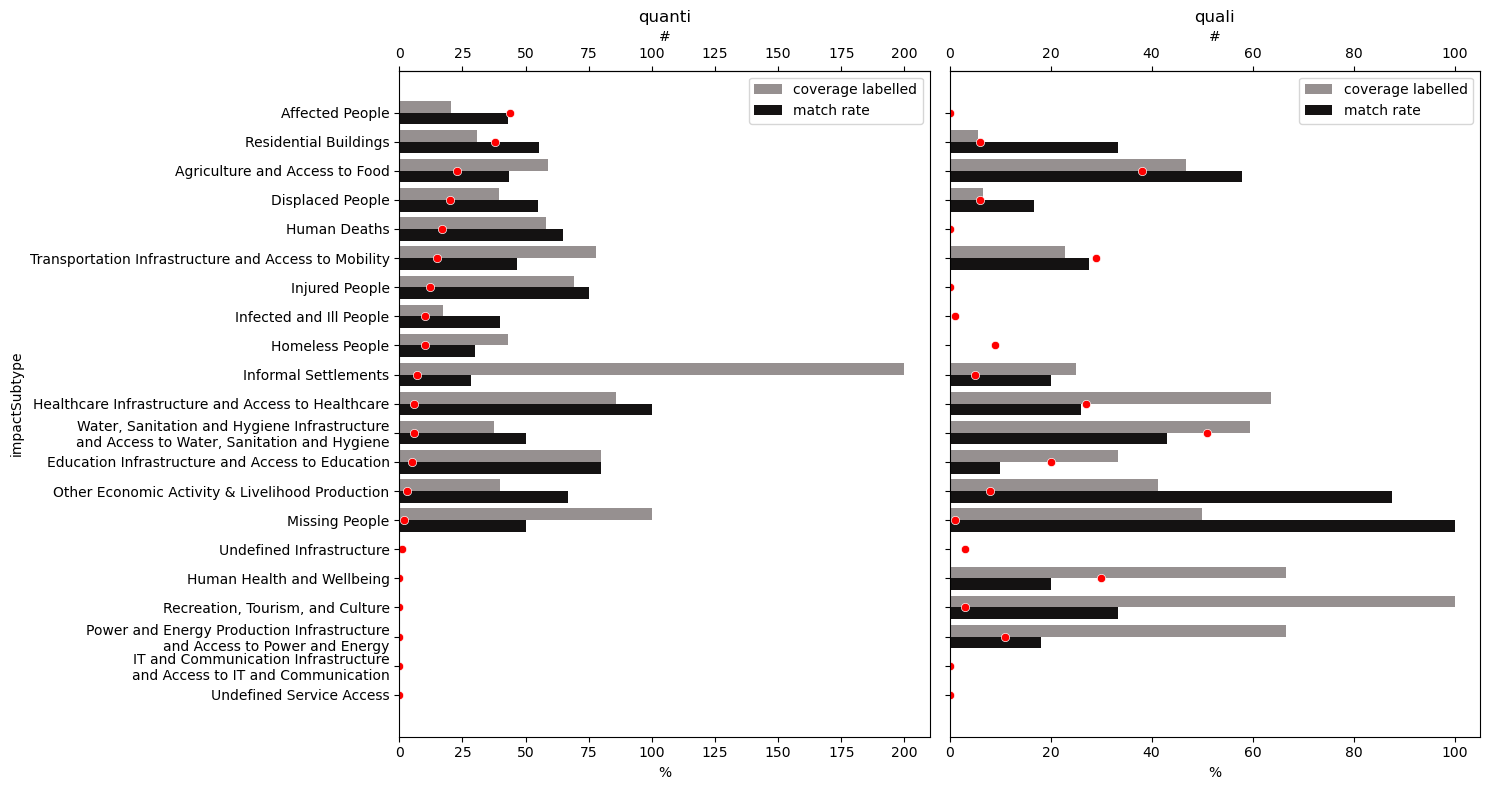

In [18]:
#prepare data
data_col = "impactSubtype"
add_avg = False
if data_col == "appealCode":
    coverage_df_match_yvar = coverage_df_match_appeal
    #sort by to look for trends
    index = extracted_df.groupby("appealCode").head(1).sort_values("reportSize", ascending=False)["appealCode"]
    coverage_df_match_yvar["appealCode"] = pd.Categorical(coverage_df_match_yvar["appealCode"], categories=index, ordered=True)
    coverage_df_match_yvar = coverage_df_match_yvar.sort_values("appealCode") #sort by size
    plot_df = coverage_df_match_yvar.melt(id_vars=["appealCode","reportSize", "reportDate", "appealType", "quanti"])
    #plot_df = coverage_df_match_yvar.melt(id_vars=[yvar, "quanti"], value_vars=value_vars, var_name="match", value_name="value")

elif data_col == "impactSubtype":
    coverage_df_match_yvar = coverage_df_match_subtype
    index = coverage_df_match_yvar.sort_values("nb extracted", ascending=False).index
    coverage_df_match_yvar = coverage_df_match_yvar.reindex(index) #sort by nb labelled
    plot_df = coverage_df_match_yvar.melt(id_vars=["impactSubtype", "quanti"])
    plot_df = plot_df[~plot_df["impactSubtype"].isin(["DREF Allocation", "Targeted People", "Assisted People"])]
if add_avg:
    average_df_match = coverage_df_match.melt(id_vars=["quanti"])
    average_df_match[data_col] ="Overall average"
    plot_df = pd.concat([average_df_match, plot_df], axis=0).reset_index(drop=True)

#choose plotting cols
subplot_vars = ["quanti", "quali"]#["nb labelled","nb matches", "nb garbage"]#["nb labelled","nb matches", "nb garbage"]#["coverage matches", "garbage"]#["nb matches", "nb garbage"]
yvar= data_col
value_col = "value"
subplot_col = "quanti"#"quanti""variable"
hue_col = "variable"#"quanti""match"
xlabels = ["%", "%"]#["#", "%", "%"]#["#", "#", "#"]#["%", "%"]#["#", "#", "#"]
hue_order = ["coverage labelled", "match rate"]
palette_rel = ["#978F8F", "#141212","#978F8F", "#141212"]
kwargs = {}
fig, axes = plt.subplots(1, len(subplot_vars), figsize=(15, 8), sharey=True, sharex=False)
fig, axes = plot_coverage_match_v2(plot_df[plot_df["variable"].isin(hue_order)], subplot_col, hue_col, subplot_vars=subplot_vars, yvar=yvar, value_col=value_col, hue_vars=hue_order, palette=palette_rel, add_avg=add_avg, fig=fig, **kwargs)
ylabels = [item.get_text() for item in axes[0].get_yticklabels()]
for i, val in enumerate(subplot_vars):
    val_df = plot_df[plot_df[subplot_col] == val]
    ax = axes[i]
    secax = ax.secondary_xaxis('top')
    val_df_scatter = val_df[val_df["variable"].isin(["nb extracted"])]
    val_df_scatter = val_df_scatter.set_index("impactSubtype").reindex(ylabels).reset_index()
    sns.scatterplot(data=val_df_scatter, x=value_col, y=yvar, ax=secax.axes, color="r")
    secax.set_xlabel("#")

#[ax.set_xlabel(xlabels[i]) for i, ax in enumerate(axes)]
#for ax in axes:
#    ax.tick_params(axis='y', labelrotation=90)
new_ylabs = []
for i, ylab in enumerate(ylabels):
    if ylab=="Water, Sanitation, and Hygiene Infrastructure and Access to Water, Sanitation, and Hygiene":
        new_txt = "Water, Sanitation and Hygiene Infrastructure\nand Access to Water, Sanitation and Hygiene"
    elif ylab=="Power and Energy Production Infrastructure and Access to Power and Energy":
        new_txt = "Power and Energy Production Infrastructure\nand Access to Power and Energy"
    elif ylab == "IT and Communication Infrastructure and Access to IT and Communication":
        new_txt = "IT and Communication Infrastructure\nand Access to IT and Communication"
    else:
        new_txt = ylab
    new_ylabs.append(new_txt)
axes[0].set_yticklabels(new_ylabs)

#axes[1].set_xlim(0, 25)
#axes[2].set_xlim(0, 25)
#fig.suptitle(f"Coverage matches by {yvar}\n{key}\nvalue_error_thresh={value_error_th}, sim_thresh={sim_th}")
fig.tight_layout()
#fig.savefig(DATA_FIGURE / f"coverage_matches_by_{yvar}_{subplot_col}_vth-{value_error_th}_sth-{sim_th}_flt_{filename_match.replace(key, MODEL_NAMES_MAP[key])}.png", bbox_inches="tight", dpi=300)

In [29]:
ylabels

['Affected People',
 'Residential Buildings',
 'Agriculture and Access to Food',
 'Displaced People',
 'Human Deaths',
 'Transportation Infrastructure and Access to Mobility',
 'Injured People',
 'Infected and Ill People',
 'Homeless People',
 'Informal Settlements',
 'Healthcare Infrastructure and Access to Healthcare',
 'Water, Sanitation, and Hygiene Infrastructure and Access to Water, Sanitation, and Hygiene',
 'Education Infrastructure and Access to Education',
 'Other Economic Activity & Livelihood Production',
 'Missing People',
 'Undefined Infrastructure',
 'Human Health and Wellbeing',
 'Recreation, Tourism, and Culture',
 'Power and Energy Production Infrastructure and Access to Power and Energy',
 'IT and Communication Infrastructure and Access to IT and Communication',
 'Undefined Service Access']

In [27]:
ylabels

[<bound method Text.get_text of Text(0, 0, 'Affected People')>,
 <bound method Text.get_text of Text(0, 1, 'Residential Buildings')>,
 <bound method Text.get_text of Text(0, 2, 'Agriculture and Access to Food')>,
 <bound method Text.get_text of Text(0, 3, 'Displaced People')>,
 <bound method Text.get_text of Text(0, 4, 'Human Deaths')>,
 <bound method Text.get_text of Text(0, 5, 'Transportation Infrastructure and Access to Mobility')>,
 <bound method Text.get_text of Text(0, 6, 'Injured People')>,
 <bound method Text.get_text of Text(0, 7, 'Infected and Ill People')>,
 <bound method Text.get_text of Text(0, 8, 'Homeless People')>,
 <bound method Text.get_text of Text(0, 9, 'Informal Settlements')>,
 <bound method Text.get_text of Text(0, 10, 'Healthcare Infrastructure and Access to Healthcare')>,
 <bound method Text.get_text of Text(0, 11, 'Water, Sanitation, and Hygiene Infrastructure and Access to Water, Sanitation, and Hygiene')>,
 <bound method Text.get_text of Text(0, 12, 'Educati

In [18]:
y_labels

[]

In [14]:
val_df

,impactSubtype,quanti,variable,value
0,"Water, Sanitation, and Hygiene Infrastructure ...",quali,nb labelled,37.0
2,Agriculture and Access to Food,quali,nb labelled,47.0
4,Human Health and Wellbeing,quali,nb labelled,9.0
5,Transportation Infrastructure and Access to Mo...,quali,nb labelled,35.0
6,Healthcare Infrastructure and Access to Health...,quali,nb labelled,11.0
...,...,...,...,...
420,IT and Communication Infrastructure and Access...,quali,garbage/coverage,NaN
423,Undefined Service Access,quali,garbage/coverage,NaN
425,Human Deaths,quali,garbage/coverage,NaN
426,Injured People,quali,garbage/coverage,NaN


In [40]:
val_df

,quanti,variable,value
impactSubtype,,,
Affected People,qualiqualiqualiqualiqualiqualiqualiqualiquali,nb labellednb extractedcoveragenb matchescover...,21.000000
Agriculture and Access to Food,qualiqualiqualiqualiqualiqualiqualiqualiquali,nb labellednb extractedcoveragenb matchescover...,351.386847
Displaced People,qualiqualiqualiqualiqualiqualiqualiqualiquali,nb labellednb extractedcoveragenb matchescover...,178.666667
Education Infrastructure and Access to Education,qualiqualiqualiqualiqualiqualiqualiqualiquali,nb labellednb extractedcoveragenb matchescover...,521.666667
Healthcare Infrastructure and Access to Healthcare,qualiqualiqualiqualiqualiqualiqualiqualiquali,nb labellednb extractedcoveragenb matchescover...,476.948052
Homeless People,qualiqualiqualiqualiqualiqualiqualiqualiquali,nb labellednb extractedcoveragenb matchescover...,570.000000
Human Deaths,qualiqualiqualiqualiqualiqualiqualiqualiquali,nb labellednb extractedcoveragenb matchescover...,5.000000
Human Health and Wellbeing,qualiqualiqualiqualiqualiqualiqualiqualiquali,nb labellednb extractedcoveragenb matchescover...,573.000000
IT and Communication Infrastructure and Access to IT and Communication,qualiqualiqualiqualiqualiqualiqualiqualiquali,nb labellednb extractedcoveragenb matchescover...,2.000000


In [38]:
sns.scatterplot(data=plot_df[plot_df["variable"].isin(["nb extracted"])], x=value_col, y=yvar, ax=secax.axes)

<Axes: xlabel='value', ylabel='impactSubtype'>

In [41]:
plot_df["variable"]

192    coverage labelled
193    coverage labelled
194    coverage labelled
195    coverage labelled
196    coverage labelled
             ...        
378           match rate
379           match rate
380           match rate
381           match rate
383           match rate
Name: variable, Length: 84, dtype: object

In [40]:
plot_df[plot_df["variable"]]

KeyError: "None of [Index(['coverage labelled', 'coverage labelled', 'coverage labelled',\n       'coverage labelled', 'coverage labelled', 'coverage labelled',\n       'coverage labelled', 'coverage labelled', 'coverage labelled',\n       'coverage labelled', 'coverage labelled', 'coverage labelled',\n       'coverage labelled', 'coverage labelled', 'coverage labelled',\n       'coverage labelled', 'coverage labelled', 'coverage labelled',\n       'coverage labelled', 'coverage labelled', 'coverage labelled',\n       'coverage labelled', 'coverage labelled', 'coverage labelled',\n       'coverage labelled', 'coverage labelled', 'coverage labelled',\n       'coverage labelled', 'coverage labelled', 'coverage labelled',\n       'coverage labelled', 'coverage labelled', 'coverage labelled',\n       'coverage labelled', 'coverage labelled', 'coverage labelled',\n       'coverage labelled', 'coverage labelled', 'coverage labelled',\n       'coverage labelled', 'coverage labelled', 'coverag

In [32]:
plot_df[plot_df["variable"].isin(hue_order)]

,impactSubtype,quanti,variable,value
192,"Water, Sanitation, and Hygiene Infrastructure ...",quali,coverage labelled,59.459459
193,Affected People,quanti,coverage labelled,20.430108
194,Agriculture and Access to Food,quali,coverage labelled,46.808511
195,Residential Buildings,quanti,coverage labelled,30.882353
196,Human Health and Wellbeing,quali,coverage labelled,66.666667
...,...,...,...,...
378,Injured People,quali,match rate,100.000000
379,Power and Energy Production Infrastructure and...,quanti,match rate,100.000000
380,IT and Communication Infrastructure and Access...,quanti,match rate,100.000000
381,Undefined Service Access,quanti,match rate,100.000000


,impactSubtype,quanti,variable,value
0,"Water, Sanitation, and Hygiene Infrastructure ...",quali,nb labelled,37.0
1,Affected People,quanti,nb labelled,93.0
2,Agriculture and Access to Food,quali,nb labelled,47.0
3,Residential Buildings,quanti,nb labelled,68.0
4,Human Health and Wellbeing,quali,nb labelled,9.0
...,...,...,...,...
427,Power and Energy Production Infrastructure and...,quanti,garbage/coverage,NaN
428,IT and Communication Infrastructure and Access...,quanti,garbage/coverage,NaN
429,Undefined Service Access,quanti,garbage/coverage,NaN
430,Assisted People,quanti,garbage/coverage,NaN


In [13]:
coverage_df_match_yvar

,impactSubtype,nb labelled,nb extracted,coverage,nb matches,coverage labelled,nb garbage,drop rate,coverage rate,garbage/coverage,quanti
42,"Water, Sanitation, and Hygiene Infrastructure ...",37,51,137.837838,22,59.459459,29,56.862745,43.137255,1.318182,quali
0,Affected People,93,44,47.311828,19,20.430108,25,56.818182,43.181818,1.315789,quanti
46,Agriculture and Access to Food,47,38,80.851064,22,46.808511,16,42.105263,57.894737,0.727273,quali
8,Residential Buildings,68,38,55.882353,21,30.882353,17,44.736842,55.263158,0.809524,quanti
31,Human Health and Wellbeing,9,30,333.333333,6,66.666667,24,80.000000,20.000000,4.000000,quali
41,Transportation Infrastructure and Access to Mo...,35,29,82.857143,8,22.857143,21,72.413793,27.586207,2.625000,quali
43,Healthcare Infrastructure and Access to Health...,11,27,245.454545,7,63.636364,20,74.074074,25.925926,2.857143,quali
22,Agriculture and Access to Food,17,23,135.294118,10,58.823529,13,56.521739,43.478261,1.300000,quanti
2,Displaced People,28,20,71.428571,11,39.285714,9,45.000000,55.000000,0.818182,quanti
45,Education Infrastructure and Access to Education,6,20,333.333333,2,33.333333,18,90.000000,10.000000,9.000000,quali


In [77]:
plot_df

,impactSubtype,quanti,variable,value
192,"Water, Sanitation, and Hygiene Infrastructure ...",quali,coverage matches,59.459459
193,Affected People,quanti,coverage matches,20.430108
194,Agriculture and Access to Food,quali,coverage matches,46.808511
195,Residential Buildings,quanti,coverage matches,30.882353
196,Human Health and Wellbeing,quali,coverage matches,66.666667
...,...,...,...,...
330,Injured People,quali,garbage,0.000000
331,Power and Energy Production Infrastructure and...,quanti,garbage,0.000000
332,IT and Communication Infrastructure and Access...,quanti,garbage,0.000000
333,Undefined Service Access,quanti,garbage,0.000000


In [64]:
plot_df

,impactSubtype,quanti,variable,value
0,"Water, Sanitation, and Hygiene Infrastructure ...",quali,nb labelled,37.0
1,Affected People,quanti,nb labelled,93.0
2,Agriculture and Access to Food,quali,nb labelled,47.0
3,Residential Buildings,quanti,nb labelled,68.0
4,Human Health and Wellbeing,quali,nb labelled,9.0
...,...,...,...,...
378,Injured People,quali,garbage/coverage,NaN
379,Power and Energy Production Infrastructure and...,quanti,garbage/coverage,NaN
380,IT and Communication Infrastructure and Access...,quanti,garbage/coverage,NaN
381,Undefined Service Access,quanti,garbage/coverage,NaN


In [25]:
labelled_df[labelled_df["impactSubtype"]=="Undefined Infrastructure"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,quanti,flag_impactSubtype_merged,geometry,appealType,flag_remove_cat
5,2019-07-19,Undefined Infrastructure,NaN,null,None,NaN,NaN,['It is also reported that embankments have be...,['Bangladesh'],"['Kurigram district', 'Gaibandha district', 'L...",...,2,34,"['Kurigram District', 'Gaibandha District', 'L...","['Bangladesh', 'Bangladesh', 'Bangladesh', 'Ba...",['BGD'],quali,False,"MULTIPOLYGON (((89.27731 21.69532, 89.27856 21...",DREF Operation,False
11,2019-07-19,Undefined Infrastructure,NaN,null,None,NaN,NaN,['of union affected 776 Emergency Plan of Acti...,['Bangladesh'],"['Gaddimari area', 'Lalmonirhats Hatibandha']",...,2,0,['Bangladesh'],"['Bangladesh', 'Bangladesh']",['BGD'],quali,False,"MULTIPOLYGON (((89.27856 21.69457, 89.28192 21...",DREF Operation,False
46,2024-08-06,Undefined Infrastructure,98.0,% structures damaged,exact,NaN,NaN,"['On July 1, the hurricane made landfall in Gr...",['Grenada'],"['Carriacou islands', 'Petit Martinique island']",...,1,0,"['Carriacou', 'Grenada']","['Grenada', 'Grenada']",['GRD'],quanti,False,"MULTIPOLYGON (((-61.65922 12.23368, -61.65757 ...",Operations Update,False
54,2024-08-06,Undefined Infrastructure,NaN,null,None,NaN,NaN,['Jamaica experienced widespread damage as Ber...,['Jamaica'],[],...,0,0,['Jamaica'],['Jamaica'],['JAM'],quali,False,"MULTIPOLYGON (((-77.81507 18.52461, -77.81086 ...",Operations Update,False
57,2024-08-06,Undefined Infrastructure,NaN,null,None,NaN,NaN,['Jamaica experienced widespread damage as Ber...,['Jamaica'],"['Clarendon', 'St. Elizabeth', 'St. Thomas', '...",...,0,0,"['Clarendon', 'Saint Elizabeth', 'Saint Thomas...","['Clarendon', 'Saint Elizabeth', 'Saint Thomas...",['JAM'],quali,False,"MULTIPOLYGON (((-77.4054 18.20686, -77.35747 1...",Operations Update,False
71,2021-12-27,Undefined Infrastructure,NaN,null,None,NaN,NaN,['The incident caused widespread damage to hou...,['Iraq'],"['Erbil', 'Kirkuk']",...,0,0,"['Erbil', 'Kirkuk']","['Erbil', 'Kirkuk']",['IRQ'],quali,False,"MULTIPOLYGON (((44.23165 35.30481, 44.13327 35...",DREF Operation,False
111,2024-04-26,Undefined Infrastructure,NaN,null,None,NaN,NaN,"['Destroyed infrastructure, health and educati...",['Kenya'],[],...,0,0,['Kenya'],['Kenya'],['KEN'],quali,False,"MULTIPOLYGON (((40.9475 -2.2245, 40.94929 -2.2...",Operations Update,False
186,2024-08-30,Undefined Infrastructure,NaN,null,approx,NaN,NaN,['Appeal MDRUG050 Total DREF Allocation CHF 47...,['Uganda'],"['Eastern Uganda-Elgon', 'Mbale', 'Kapchorwa',...",...,1,9,"['Uganda', 'Mbale', 'Kapchorwa', 'Bulambuli', ...","['Uganda', 'Uganda', 'Uganda', 'Uganda', 'Ugan...",['UGA'],quali,False,"MULTIPOLYGON (((29.60806 -1.31797, 29.60806 -1...",DREF Operation Update,False
300,2025-03-28,Undefined Infrastructure,NaN,null,approx,NaN,NaN,['Pakistan endured an exceptionally intense mo...,['Pakistan'],[],...,0,0,['Pakistan'],['Pakistan'],['PAK'],quali,False,"MULTIPOLYGON (((68.18137 23.77964, 68.17335 23...",DREF Operation Final Report,False
306,2025-03-28,Undefined Infrastructure,NaN,null,approx,NaN,NaN,"['Sindh experienced acute urban flooding, part...",['Pakistan'],"['Sindh', 'Badin', 'Dadu', 'Jacobabad']",...,0,0,"['Sindh', 'Badin', 'Dadu', 'Jacobabad']","['Sindh', 'Sindh', 'Balochistan', 'Balochistan']",['PAK'],quali,False,"MULTIPOLYGON (((68.07541 23.78586, 68.07623 23...",DREF Operation Final Report,False


In [12]:
un_matched = matched_df_filter1[(matched_df_filter1["match_sim"] <= sim_th)]
un_matched_quali = un_matched[(matched_df_filter1["quanti"] == "quali")]
un_matched_quanti = un_matched[(matched_df_filter1["quanti"] == "quanti")]


/Users/lseverino/miniforge3/envs/ifrc_llm_311/lib/python3.11/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)
/Users/lseverino/miniforge3/envs/ifrc_llm_311/lib/python3.11/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


In [24]:
un_matched_quali.impactSubtype.value_counts()

impactSubtype
Healthcare Infrastructure and Access to Healthcare                                            17
Human Health and Wellbeing                                                                    14
Education Infrastructure and Access to Education                                               9
Other Economic Activity & Livelihood Production                                                9
Water, Sanitation, and Hygiene Infrastructure and Access to Water, Sanitation, and Hygiene     5
Agriculture and Access to Food                                                                 4
Undefined Infrastructure                                                                       2
Homeless People                                                                                1
Transportation Infrastructure and Access to Mobility                                           1
Name: count, dtype: int64

In [16]:
un_matched.impactSubtype.value_counts()

impactSubtype
Education Infrastructure and Access to Education                                              21
Healthcare Infrastructure and Access to Healthcare                                            19
Other Economic Activity & Livelihood Production                                                9
Human Health and Wellbeing                                                                     7
Informal Settlements                                                                           7
Residential Buildings                                                                          6
Water, Sanitation, and Hygiene Infrastructure and Access to Water, Sanitation, and Hygiene     4
Transportation Infrastructure and Access to Mobility                                           4
Agriculture and Access to Food                                                                 4
Homeless People                                                                                3
Power and Energy

In [22]:
cat = "Healthcare Infrastructure and Access to Healthcare"
ext_df = extracted_df_filter[extracted_df_filter["impactSubtype"]==cat]
lab_df = labelled_df_filter[labelled_df_filter["impactSubtype"]==cat]
m_df1 = matched_df_filter1[matched_df_filter1["impactSubtype"]==cat]
m_df2 = matched_df_filter2[matched_df_filter2["impactSubtype"]==cat]
make_coverage_accuracy_df(ext_df, lab_df, m_df2, group_key="impactSubtype", group_keys=[cat]).reset_index(drop=False, names=["impactSubtype"])

,impactSubtype,nb labelled,nb extracted,coverage,nb matches,coverage matches,nb garbage,garbage,garbage/coverage,quanti
0,Healthcare Infrastructure and Access to Health...,7,6,85.714286,5,71.428571,1,16.666667,0.200000,quanti
1,Healthcare Infrastructure and Access to Health...,8,15,187.500000,7,87.500000,8,53.333333,1.142857,quali


In [20]:
print_match(m_df1[m_df1["match_sim"] < 0.5])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
52,MDRBJ019,Education Infrastructure and Access to Education,Agriculture and Access to Food,NaN,NaN,null,null,"['Couffo', 'Mono', 'Zou', 'Ouémé', 'Adoukandji...","['Mono', 'Couffo', 'Zou', 'Ouémé']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.470849,['The localities will feel the effect of this ...,['DREF Operation Benin_Flood in Lalo Field vis...
53,MDRBJ019,Education Infrastructure and Access to Education,Other Economic Activity & Livelihood Production,NaN,NaN,null,null,"['Couffo', 'Mono', 'Zou', 'Ouémé', 'Adoukandji...","['Mono', 'Couffo', 'Zou', 'Ouémé']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.470849,['The localities will feel the effect of this ...,['DREF Operation Benin_Flood in Lalo Field vis...
54,MDRBJ019,Education Infrastructure and Access to Education,Human Health and Wellbeing,NaN,NaN,null,null,"['Couffo', 'Mono', 'Zou', 'Ouémé', 'Adoukandji...","['Mono', 'Couffo', 'Zou', 'Ouémé']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.470849,['The localities will feel the effect of this ...,['DREF Operation Benin_Flood in Lalo Field vis...
55,MDRBJ019,Education Infrastructure and Access to Education,"Water, Sanitation, and Hygiene Infrastructure ...",NaN,NaN,null,null,"['Couffo', 'Mono', 'Zou', 'Ouémé', 'Adoukandji...","['Mono', 'Couffo', 'Zou', 'Ouémé']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.470849,['The localities will feel the effect of this ...,['DREF Operation Benin_Flood in Lalo Field vis...
56,MDRBJ019,Education Infrastructure and Access to Education,Agriculture and Access to Food,NaN,NaN,null,null,"['Couffo', 'Mono', 'Zou', 'Ouémé', 'Adoukandji...","['Mono', 'Couffo', 'Zou', 'Ouémé']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.470849,['The localities will feel the effect of this ...,['DREF Operation Benin_Flood in Lalo Field vis...
112,MDRDZ011,Education Infrastructure and Access to Education,Other Economic Activity & Livelihood Production,NaN,NaN,null,null,"['Béchar', 'Tamanrasset', 'El Bayadh', 'Beni A...","['Béchar', 'Elbayadh', 'Beni Abbes', 'Tamanras...",0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.500000,0.481481,['The affected populations are facing immediat...,['DREF Operation Algeria Flood 2024 Bechar App...
113,MDRDZ011,Education Infrastructure and Access to Education,Other Service Access Impacts,NaN,NaN,null,null,"['Béchar', 'Tamanrasset', 'El Bayadh', 'Beni A...","['Béchar', 'Elbayadh', 'Beni Abbes', 'Tamanras...",0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.500000,0.481481,['The affected populations are facing immediat...,['DREF Operation Algeria Flood 2024 Bechar App...
114,MDRDZ011,Education Infrastructure and Access to Education,Transportation Infrastructure and Access to Mo...,NaN,NaN,null,null,"['Béchar', 'Tamanrasset', 'El Bayadh', 'Beni A...","['Béchar', 'Elbayadh', 'Beni Abbes', 'Tamanras...",0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.500000,0.481481,['The affected populations are facing immediat...,['DREF Operation Algeria Flood 2024 Bechar App...
115,MDRDZ011,Education Infrastructure and Access to Education,Power and Energy Production Infrastructure and...,NaN,NaN,null,null,"['Béchar', 'Tamanrasset', 'El Bayadh', 'Beni A...","['Béchar', 'Elbayadh', 'Beni Abbes', 'Tamanras...",0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.500000,0.481481,['The affected populations are facing immediat...,['DREF Operation Algeria Flood 2024 Bechar App...
116,MDRDZ011,Education Infrastructure and Access to Education,"Water, Sanitation, and Hygiene Infrastructure ...",NaN,NaN,null,null,"['Béchar', 'Tamanrasset', 'El Bayadh', 'Beni A...","['Béchar', 'Elbayadh', 'Beni Abbes', 'Tamanras...",0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.500000,0.481481,['The affected populations are facing immediat...,['DREF Operation Algeria Flood 2024 Bechar App...


In [56]:
print_match(matched_df_filter1[(matched_df_filter1["impactSubtype_sim"] <= 0.8)]).value_counts("impactSubtype")

impactSubtype
Other Human Impacts                                                                           22
Healthcare Infrastructure and Access to Healthcare                                            20
Other Infrastructural Impacts                                                                 19
Human Health and Wellbeing                                                                    18
Other Service Access Impacts                                                                  15
Power and Energy Production Infrastructure and Access to Power and Energy                     12
Other Economic Activity & Livelihood Production                                               10
Water, Sanitation, and Hygiene Infrastructure and Access to Water, Sanitation, and Hygiene     9
Education Infrastructure and Access to Education                                               6
Transportation Infrastructure and Access to Mobility                                           5
Homeless People 

In [159]:
un_matched = matched_df_filter1[(matched_df_filter1["match_sim"] <= 0.5) & (matched_df_filter1["quanti"] == "quali")]
for groupid, group in un_matched.groupby("impactSubtype"):
    print(groupid)
    print(group.value_counts("impactSubtype_matched"))

Access to Food
impactSubtype_matched
Other Infrastructural Impacts                      3
Other Economic Activity & Livelihood Production    2
Residential Buildings                              2
Water, Sanitation, and Hygiene Infrastructure      2
Affected Livestock and Animals                     1
Crop Production and Forestry                       1
Education Infrastructure                           1
Healthcare Infrastructure                          1
Human Health and Wellbeing                         1
Other Service Access Impacts                       1
Water Quality and Availability                     1
Name: count, dtype: int64
Access to Healthcare
impactSubtype_matched
Other Economic Activity & Livelihood Production    3
Residential Buildings                              3
Road Infrastructure                                2
Water Quality and Availability                     2
Access to Food                                     1
Agricultural Infrastructure                   

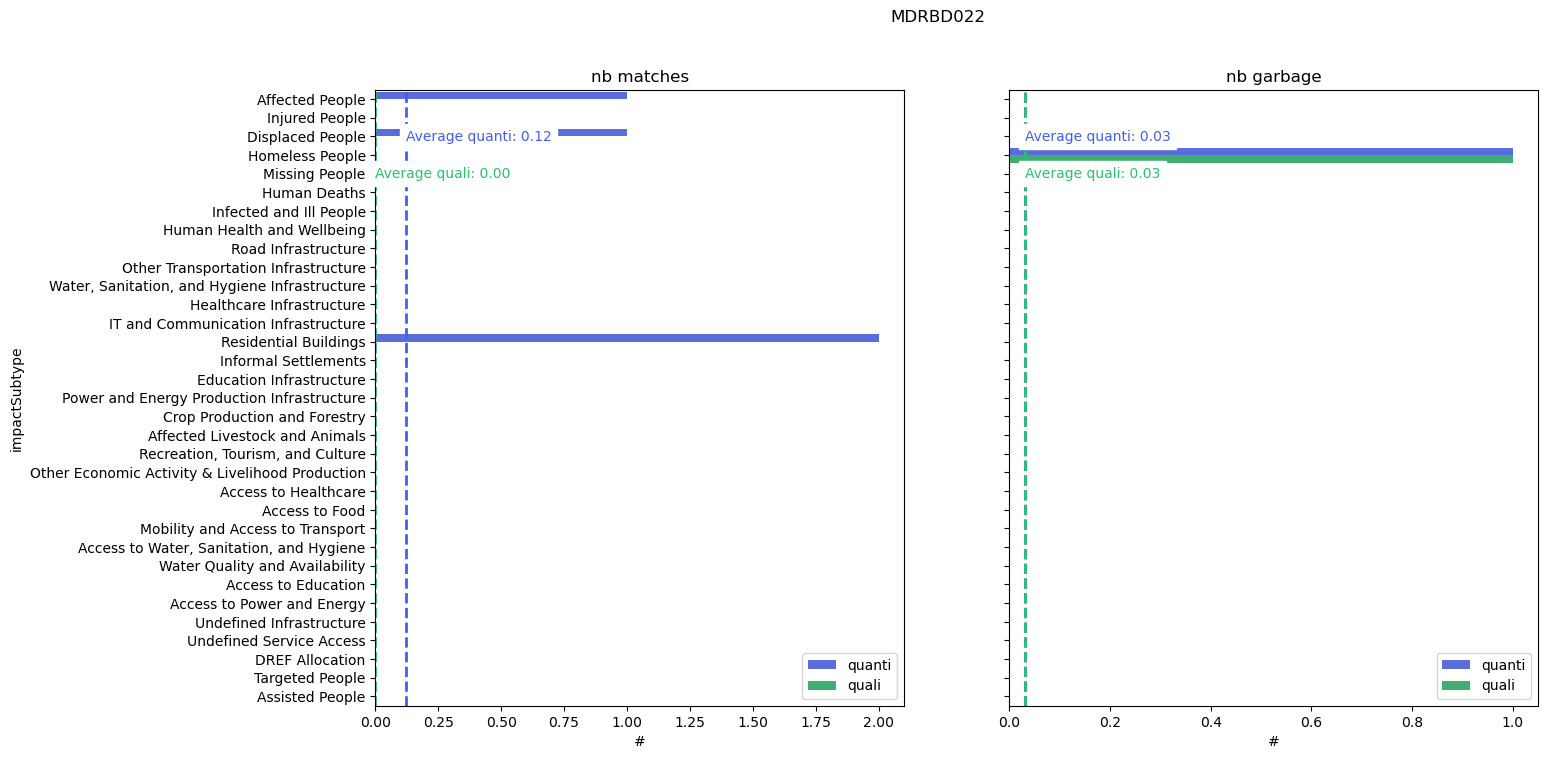

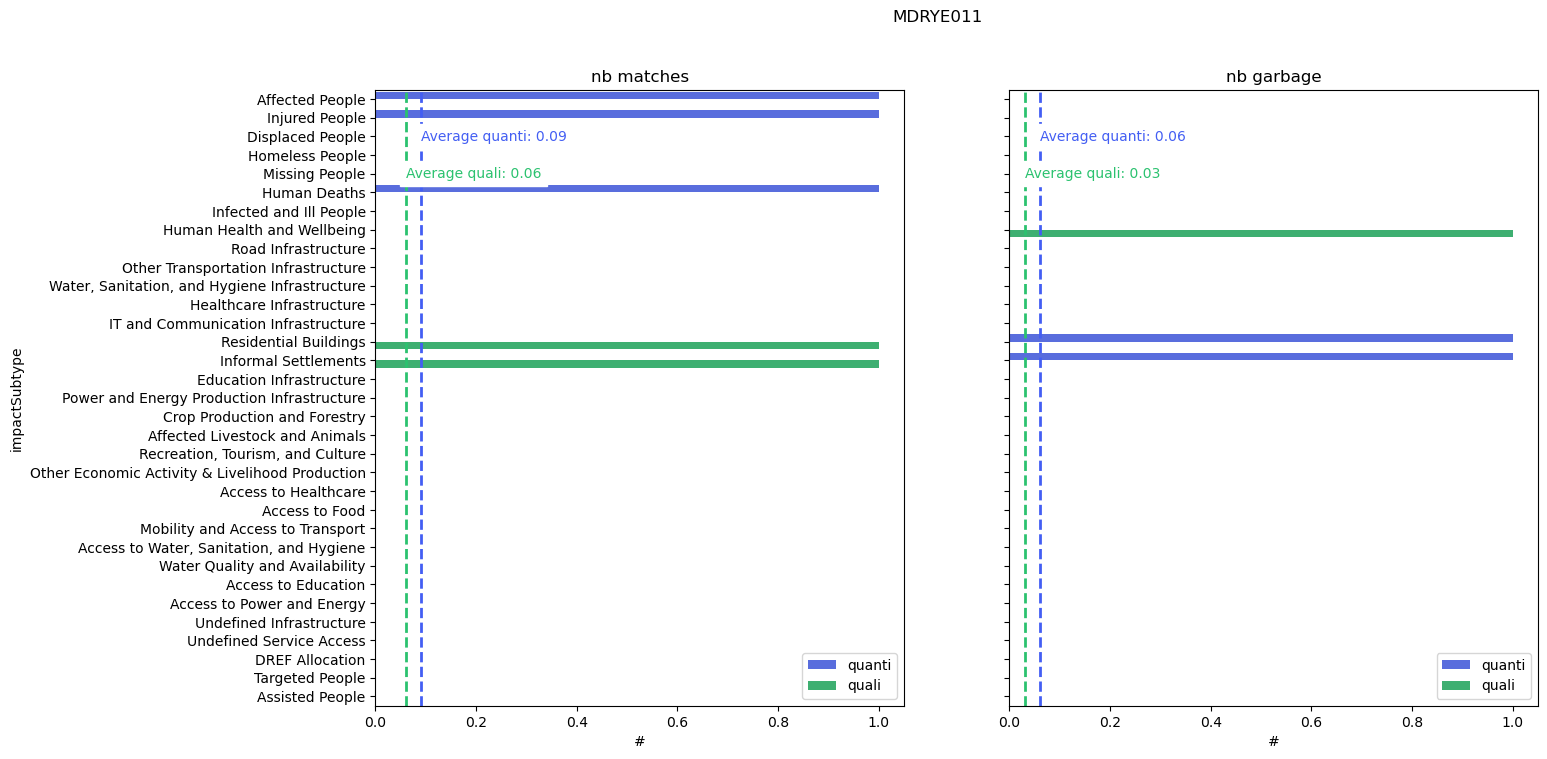

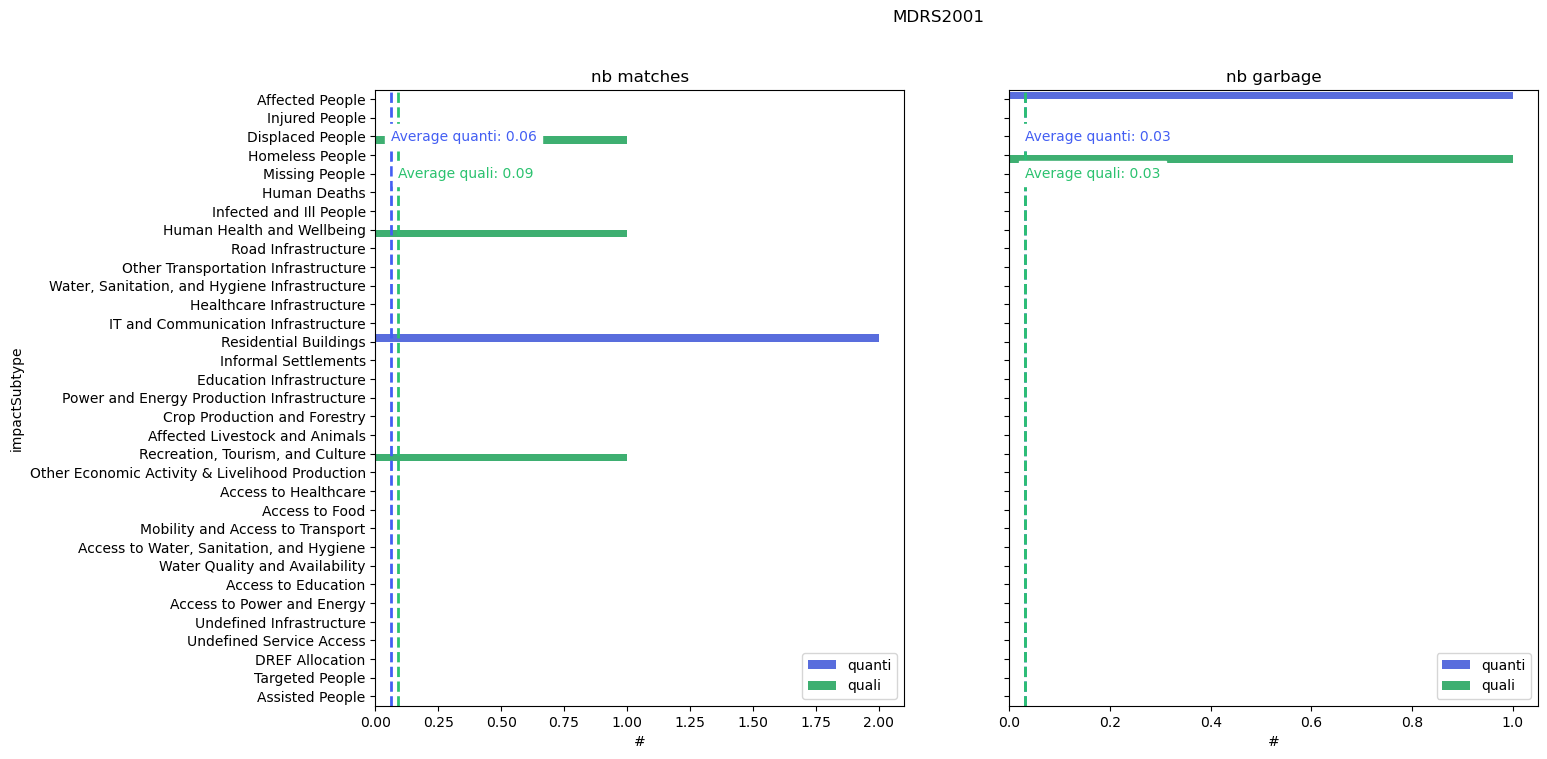

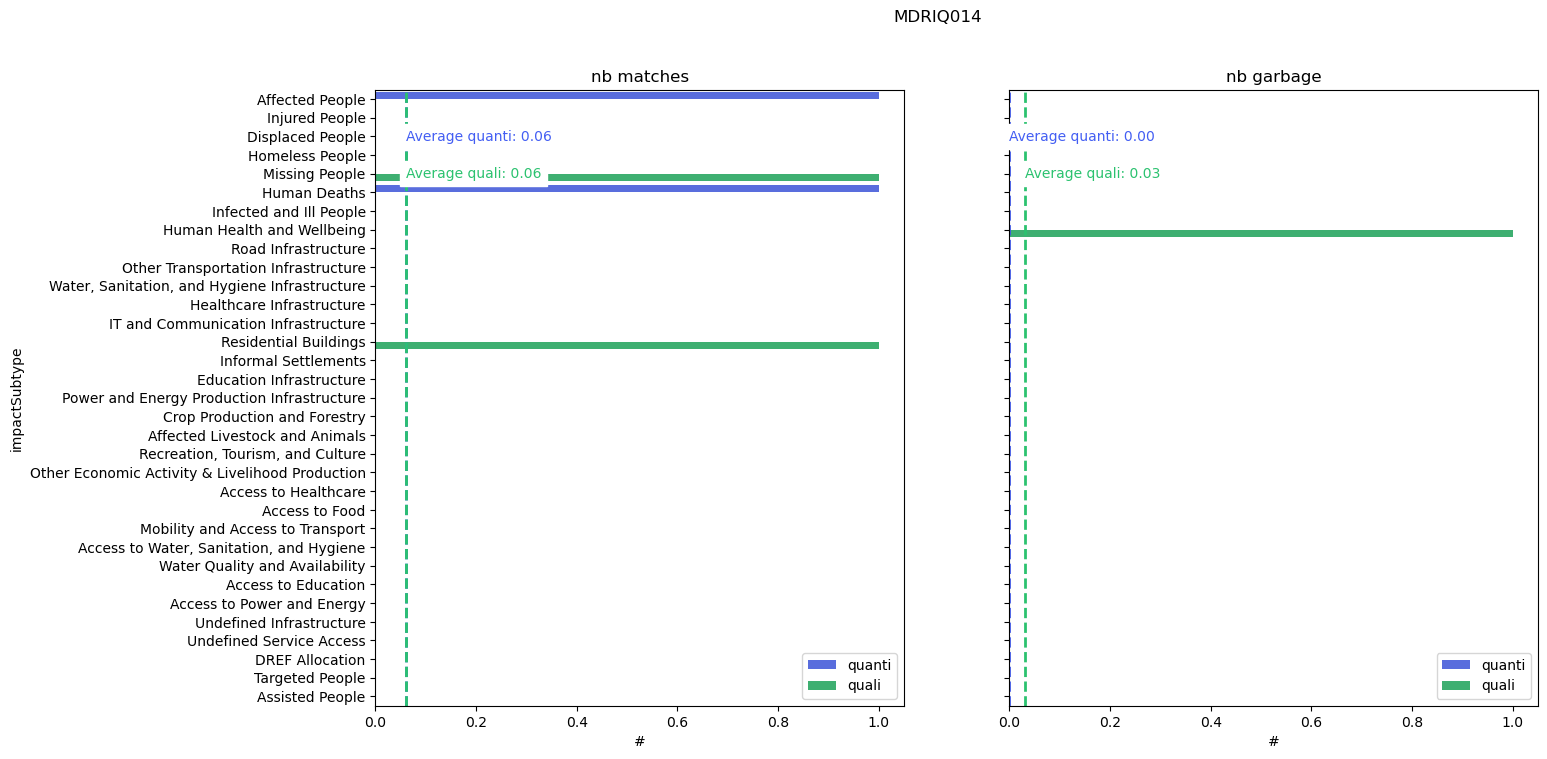

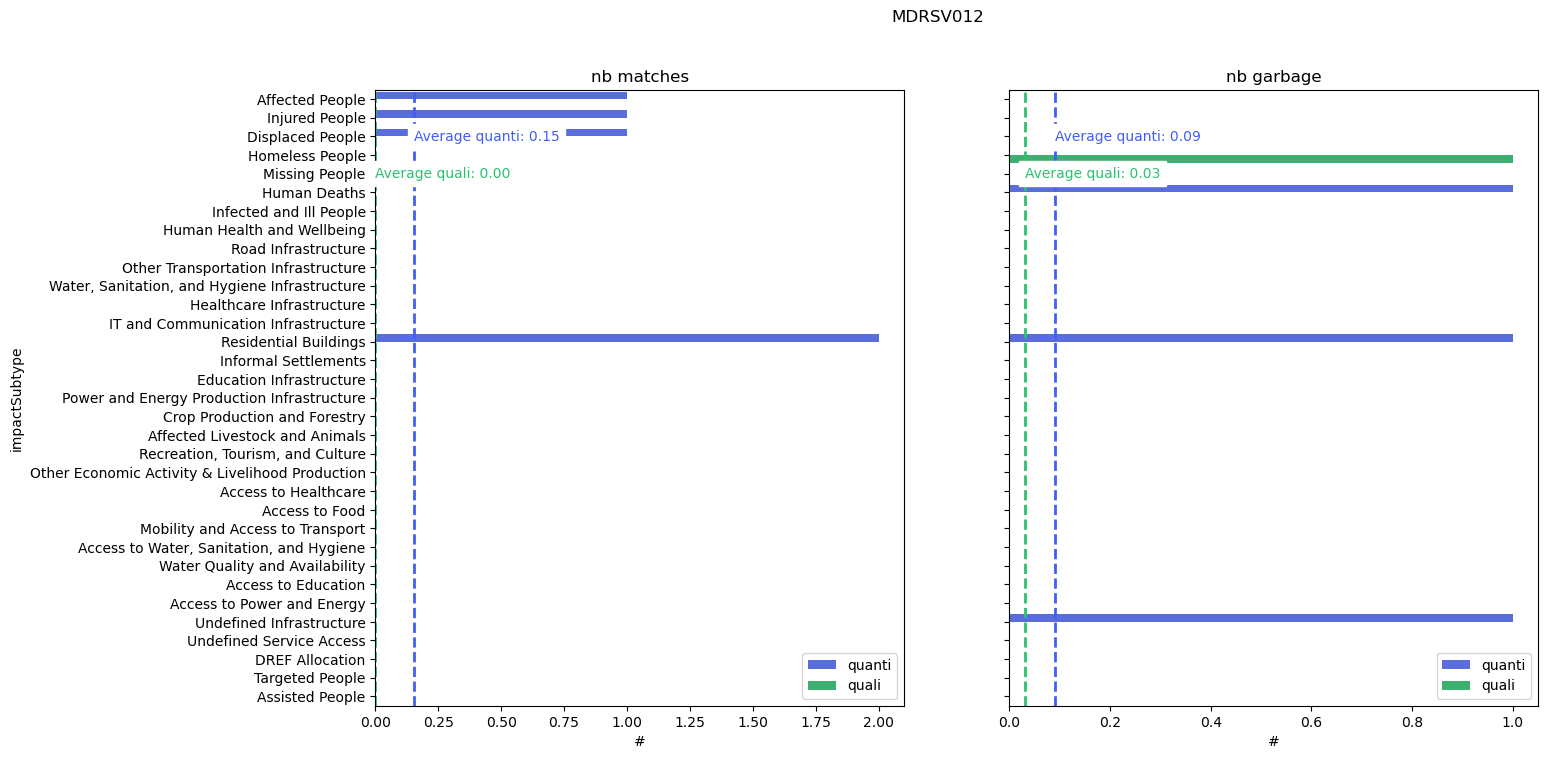

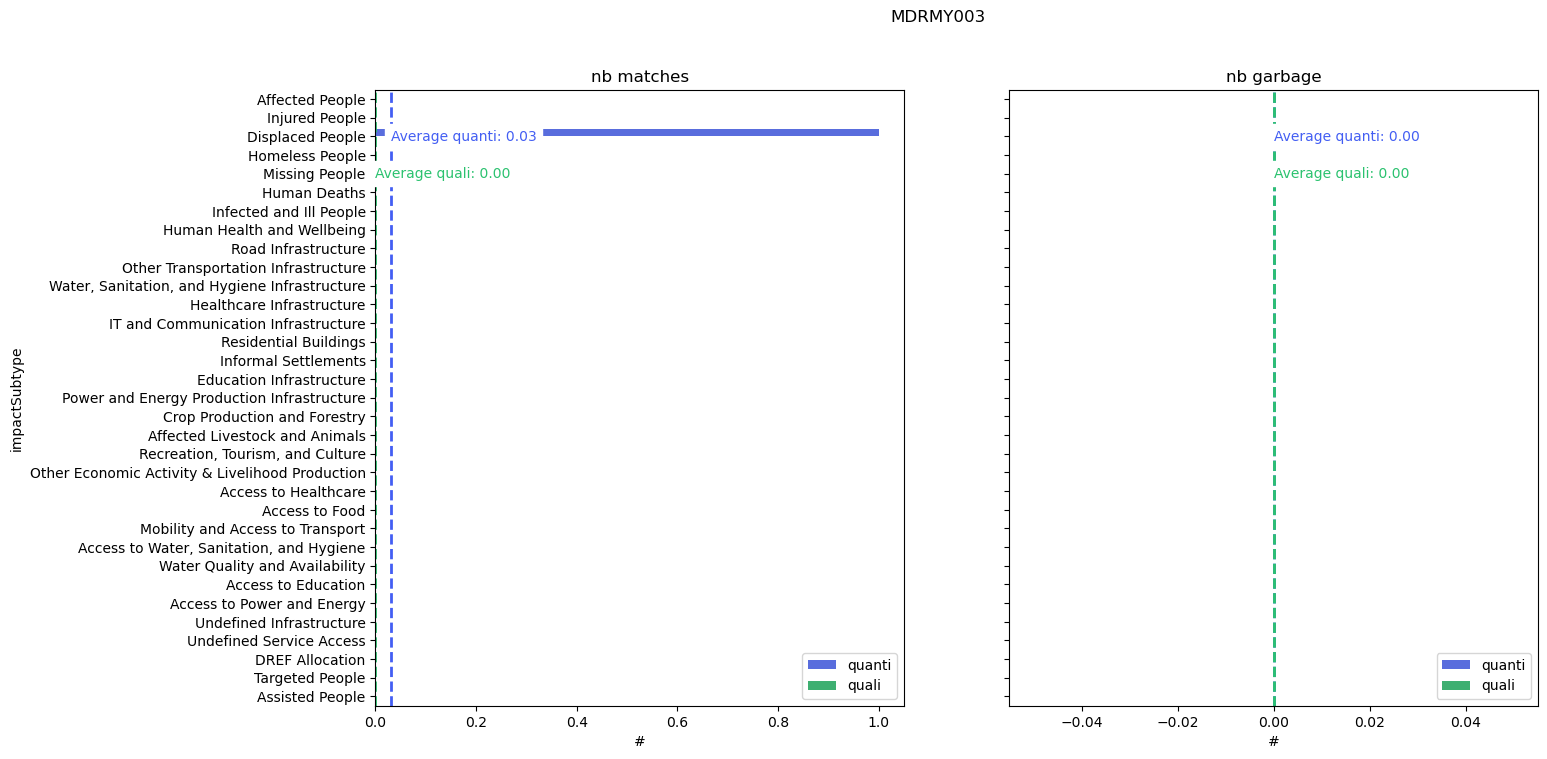

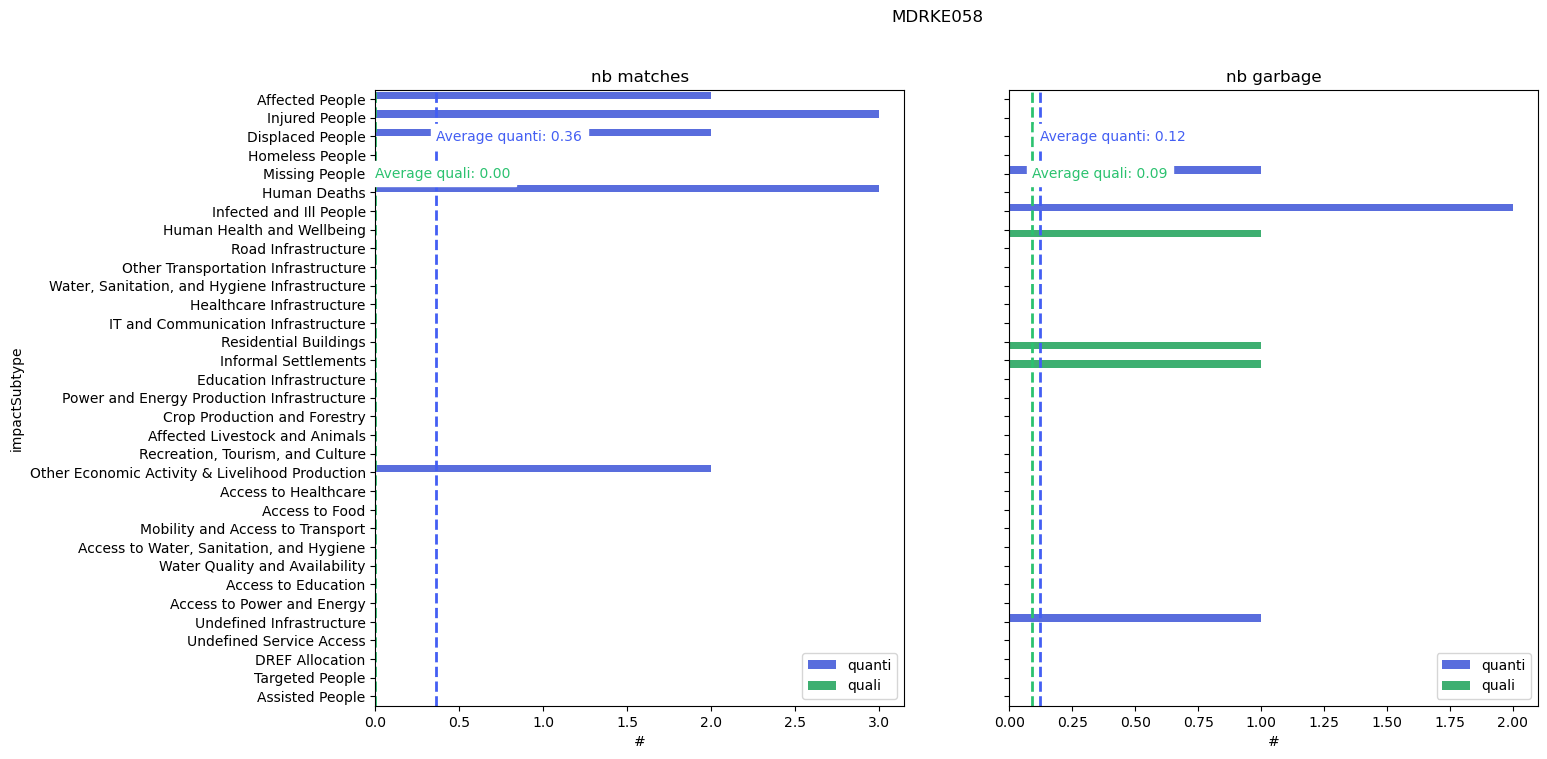

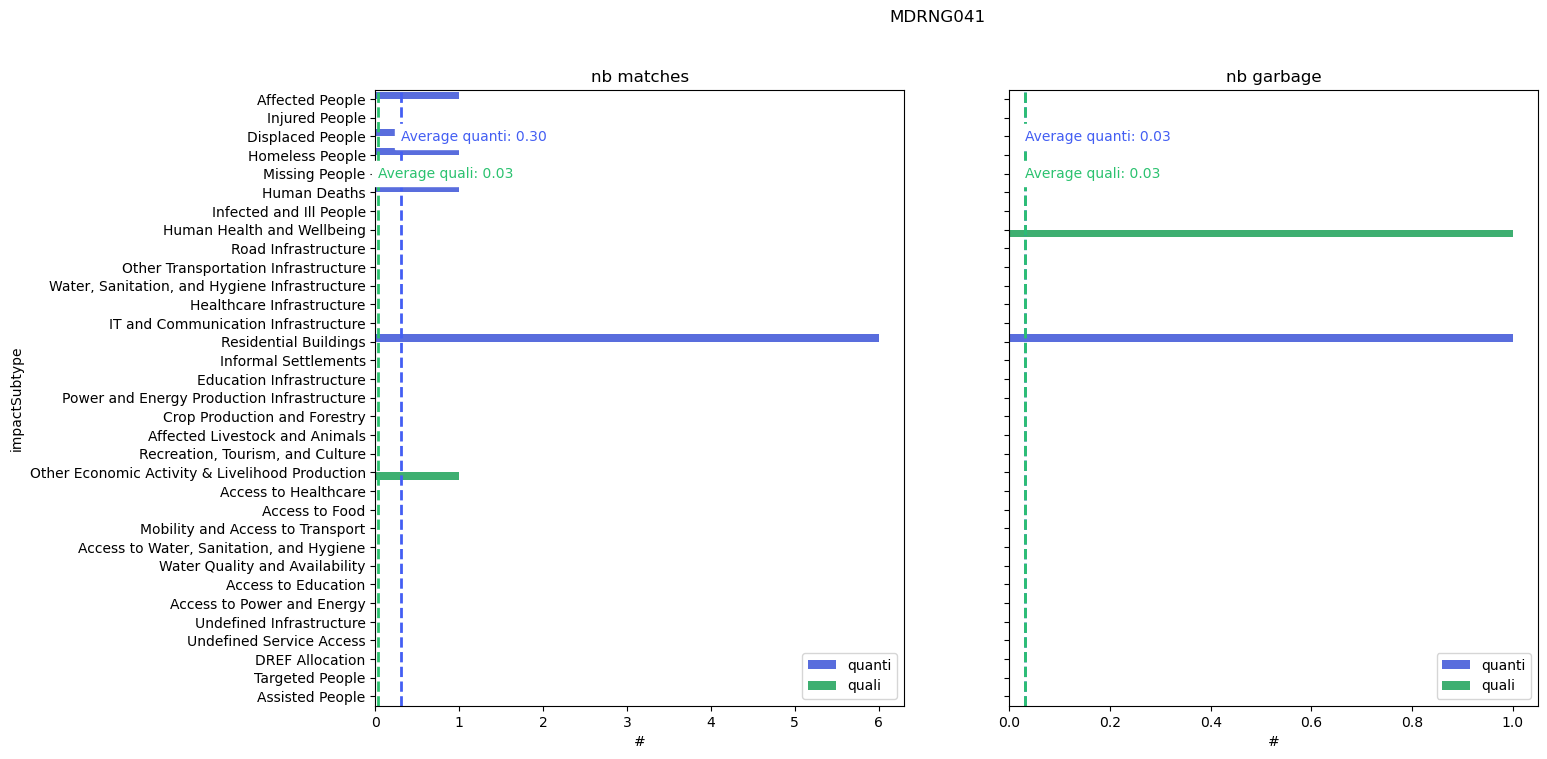

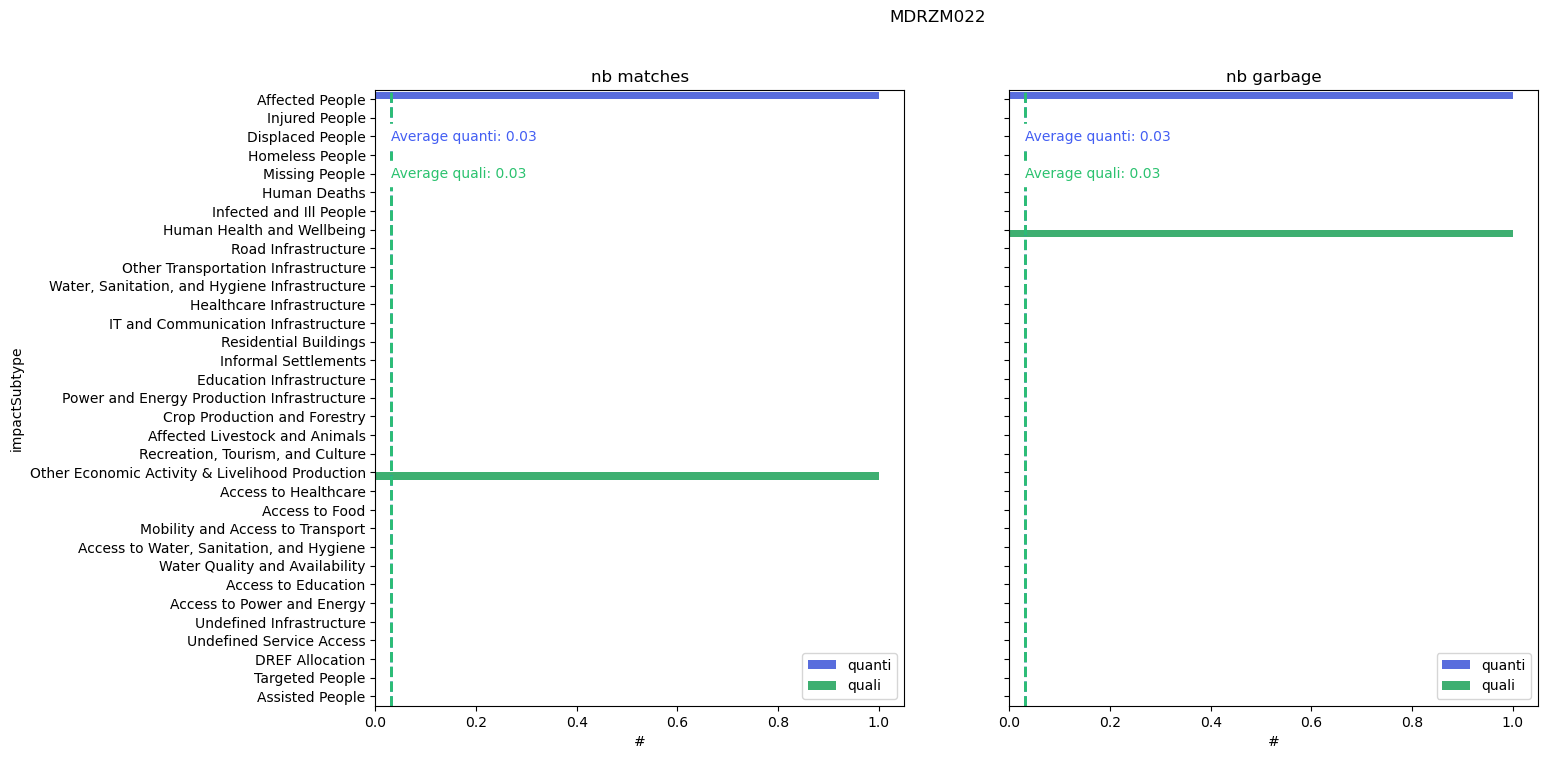

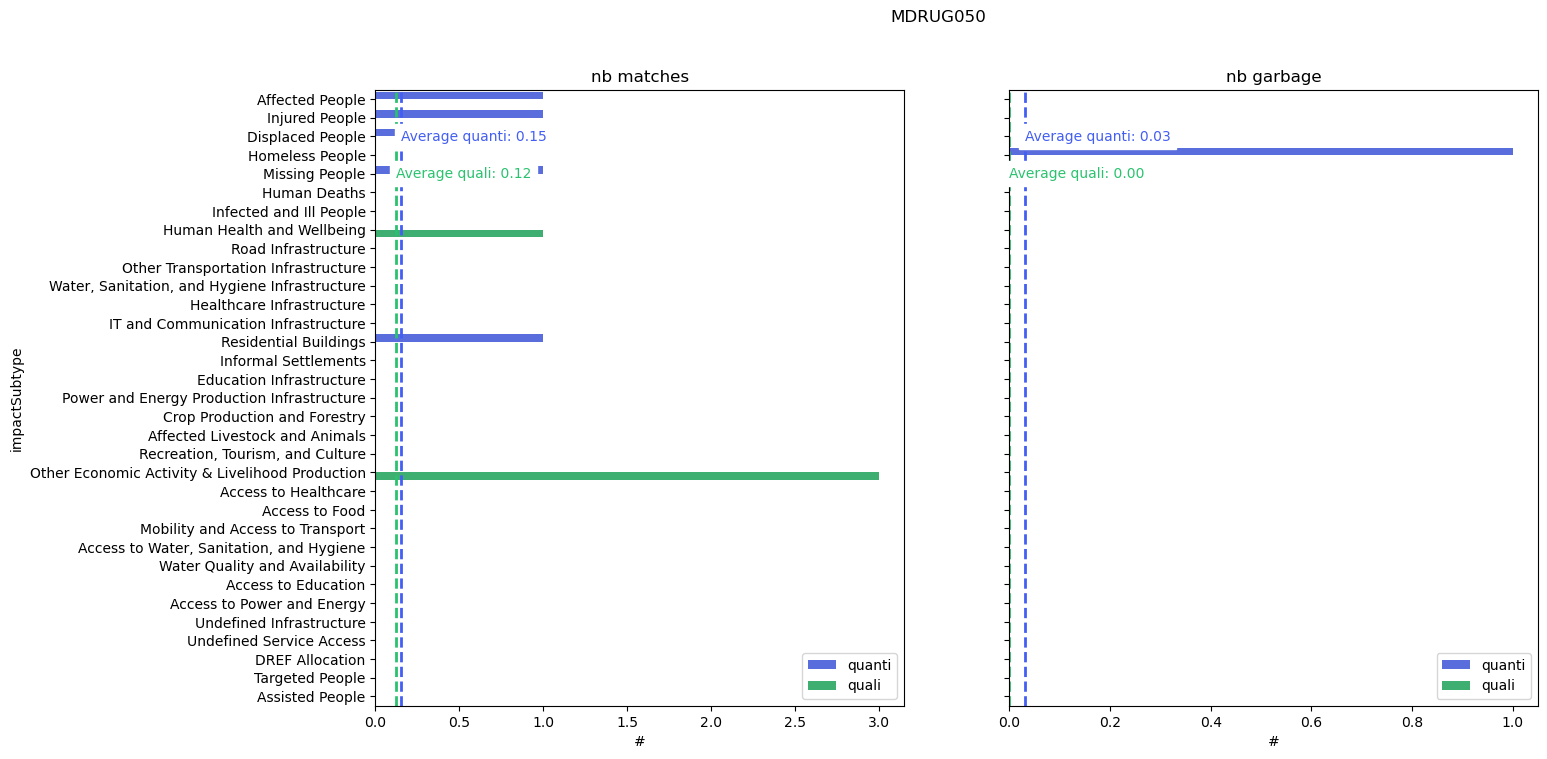

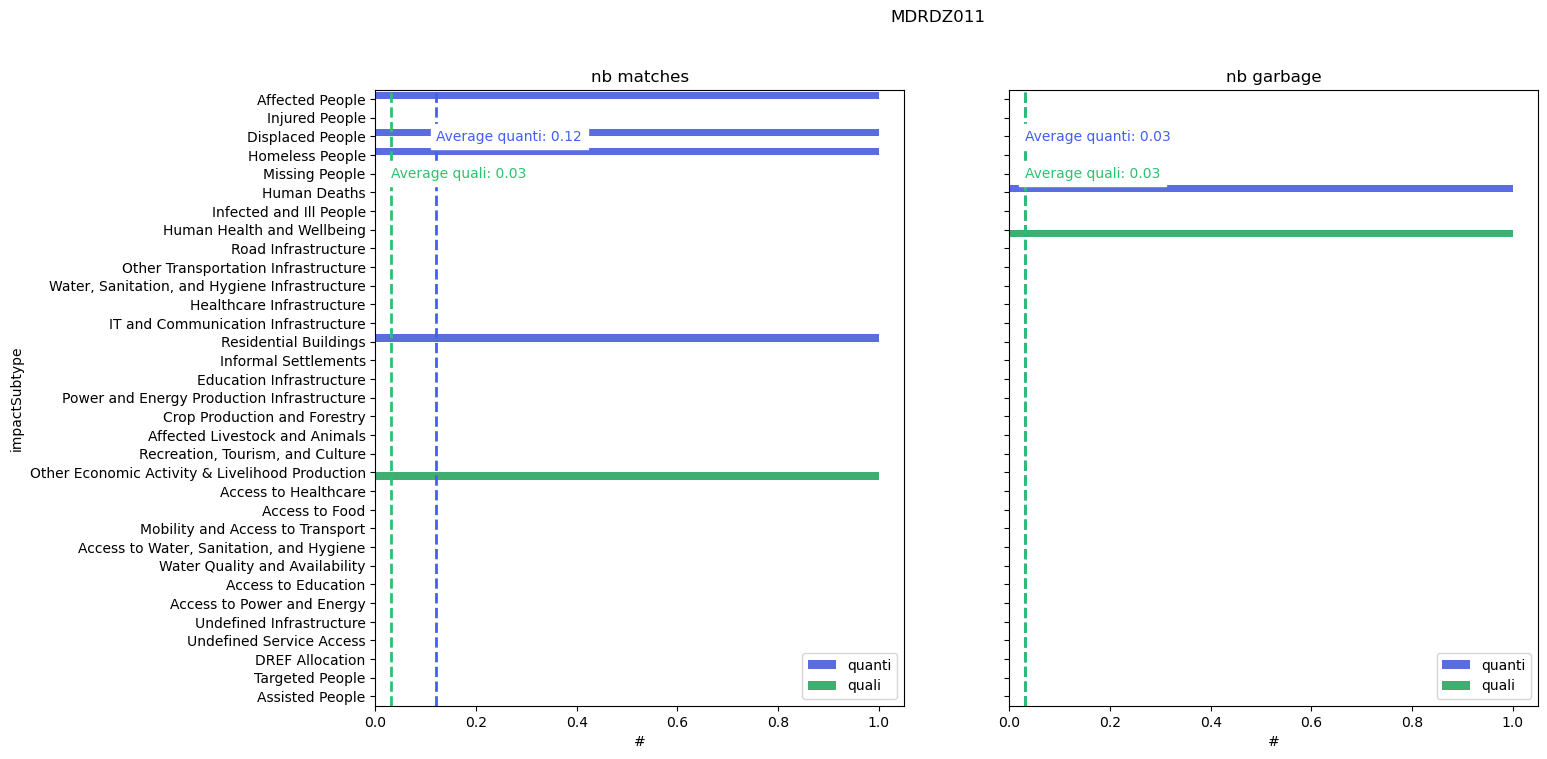

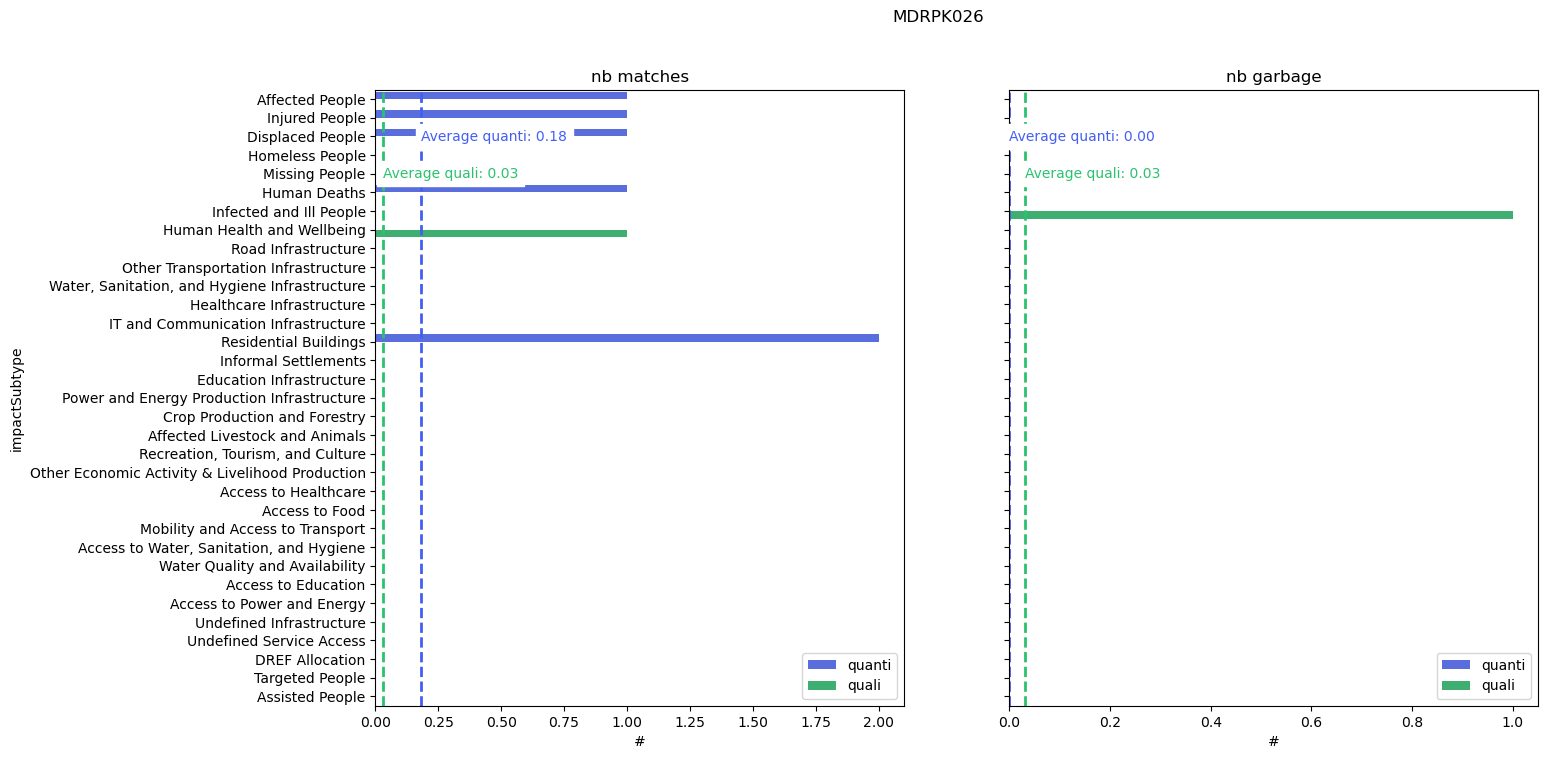

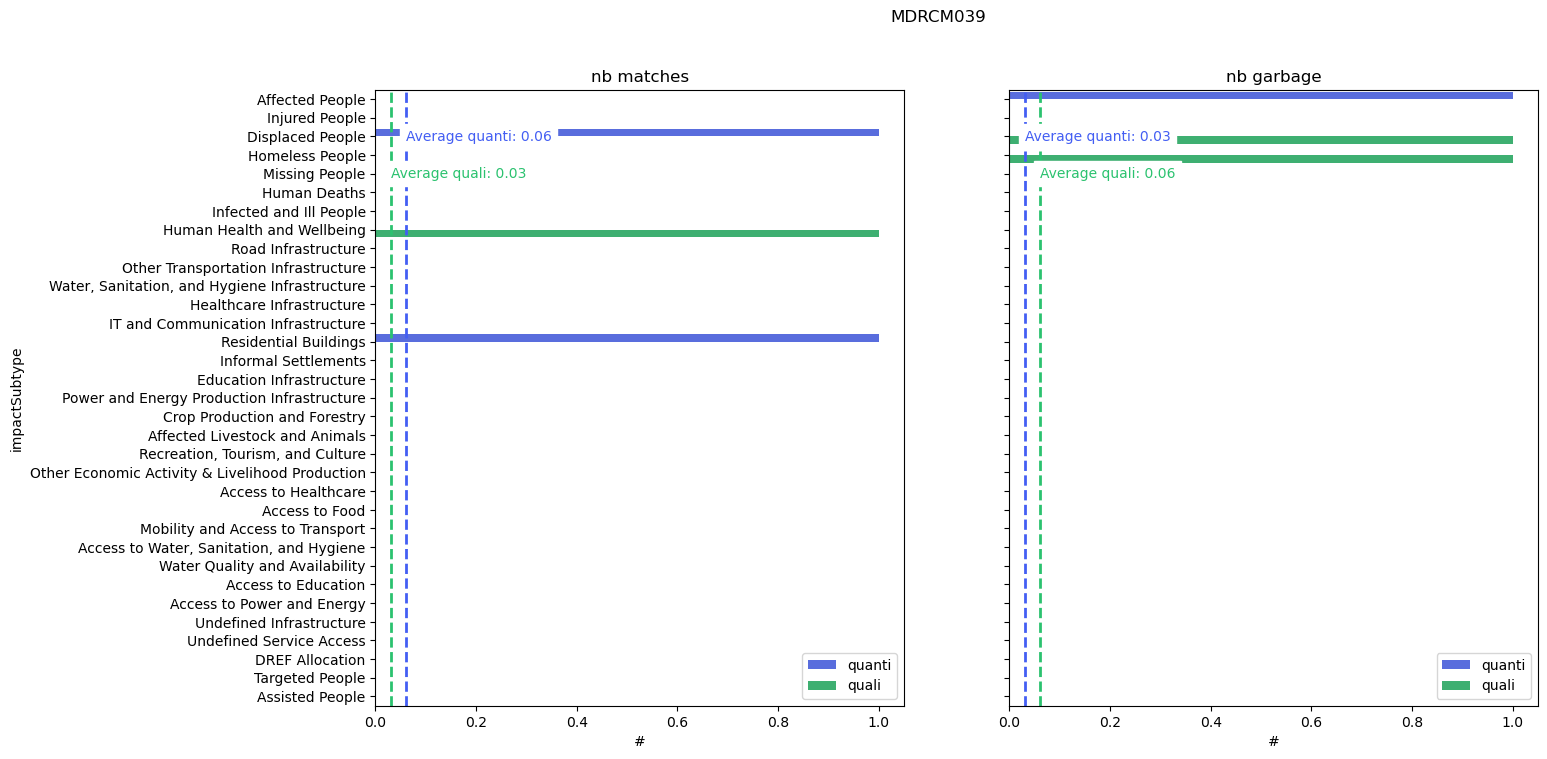

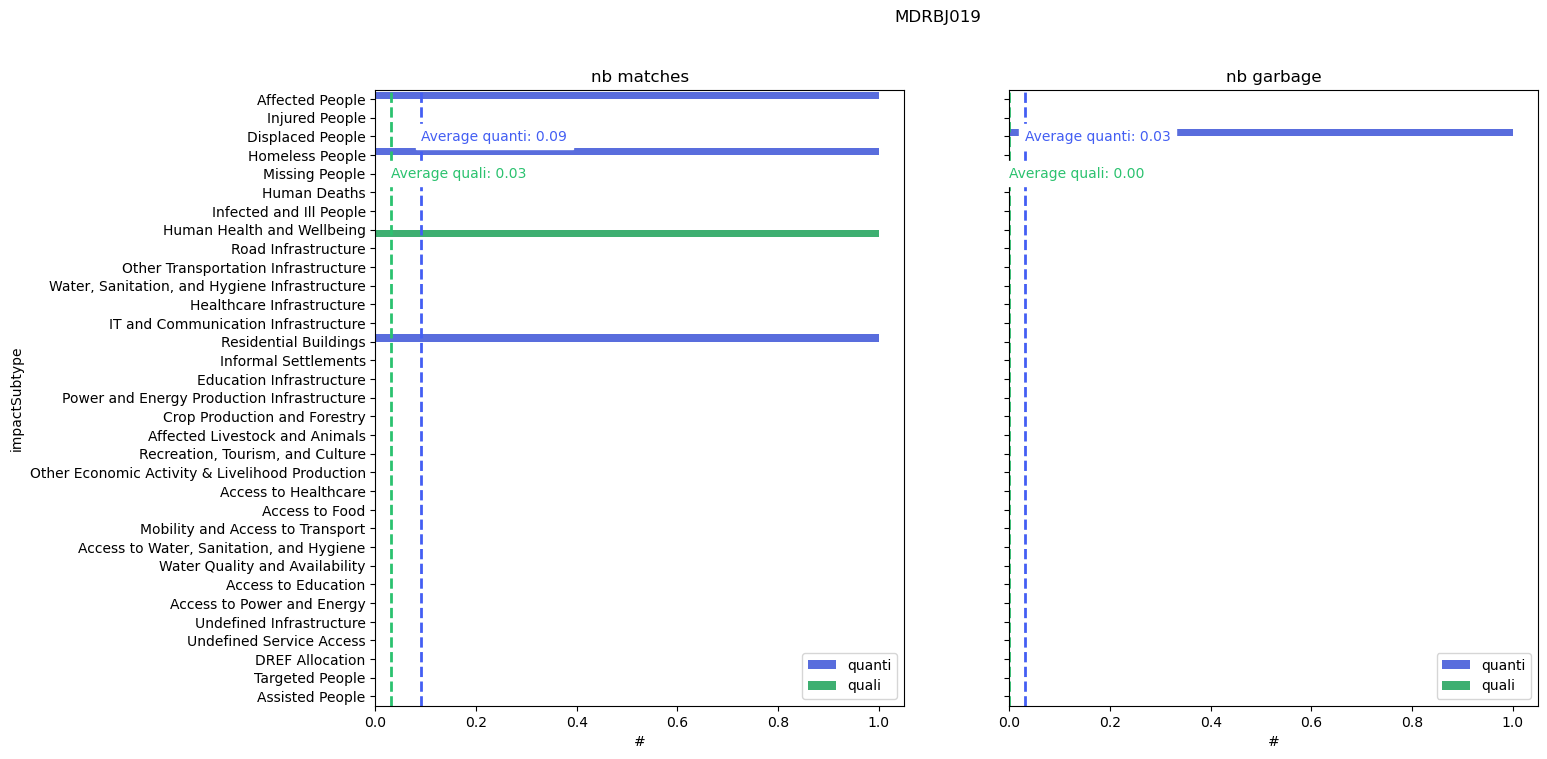

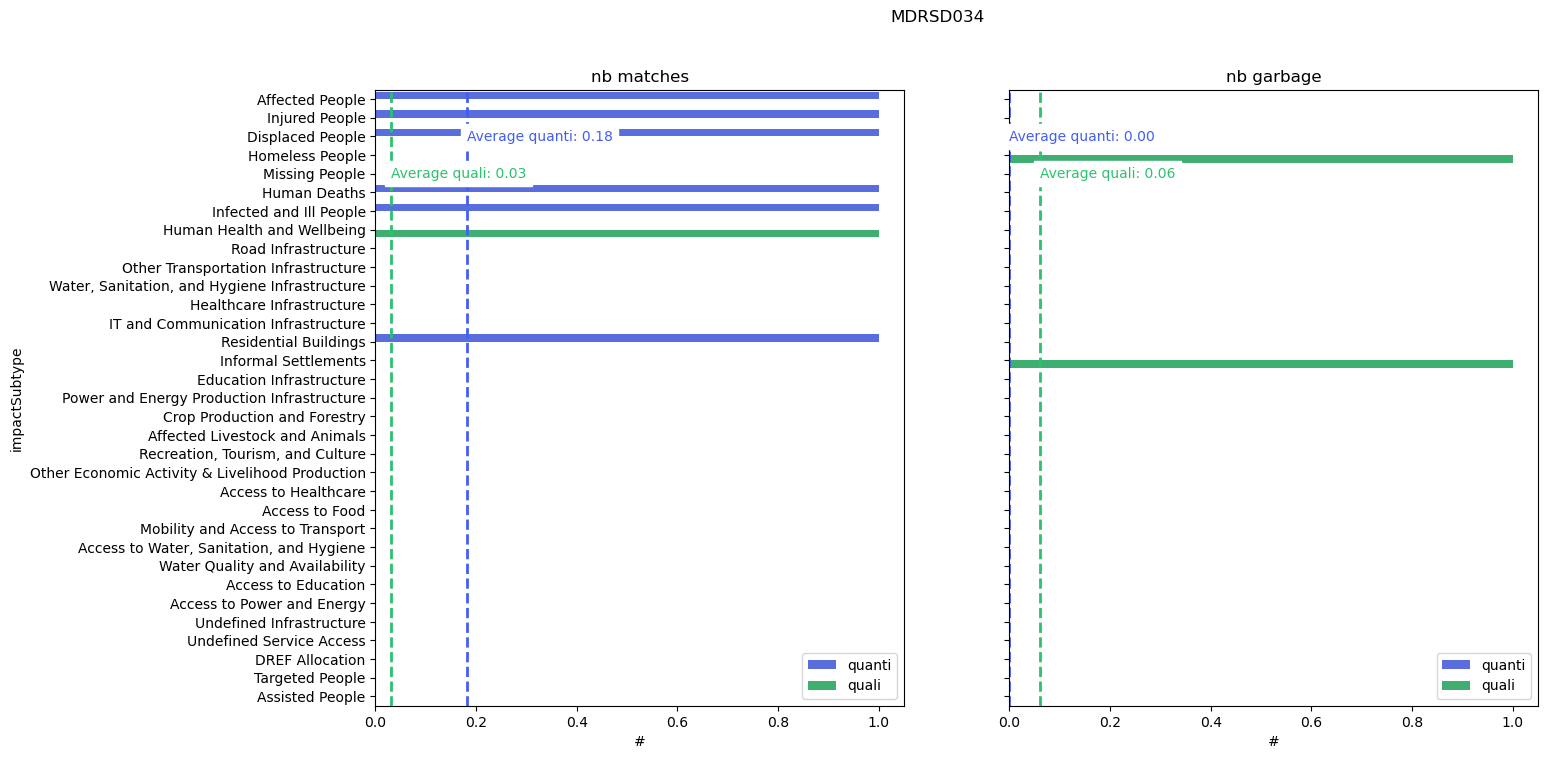

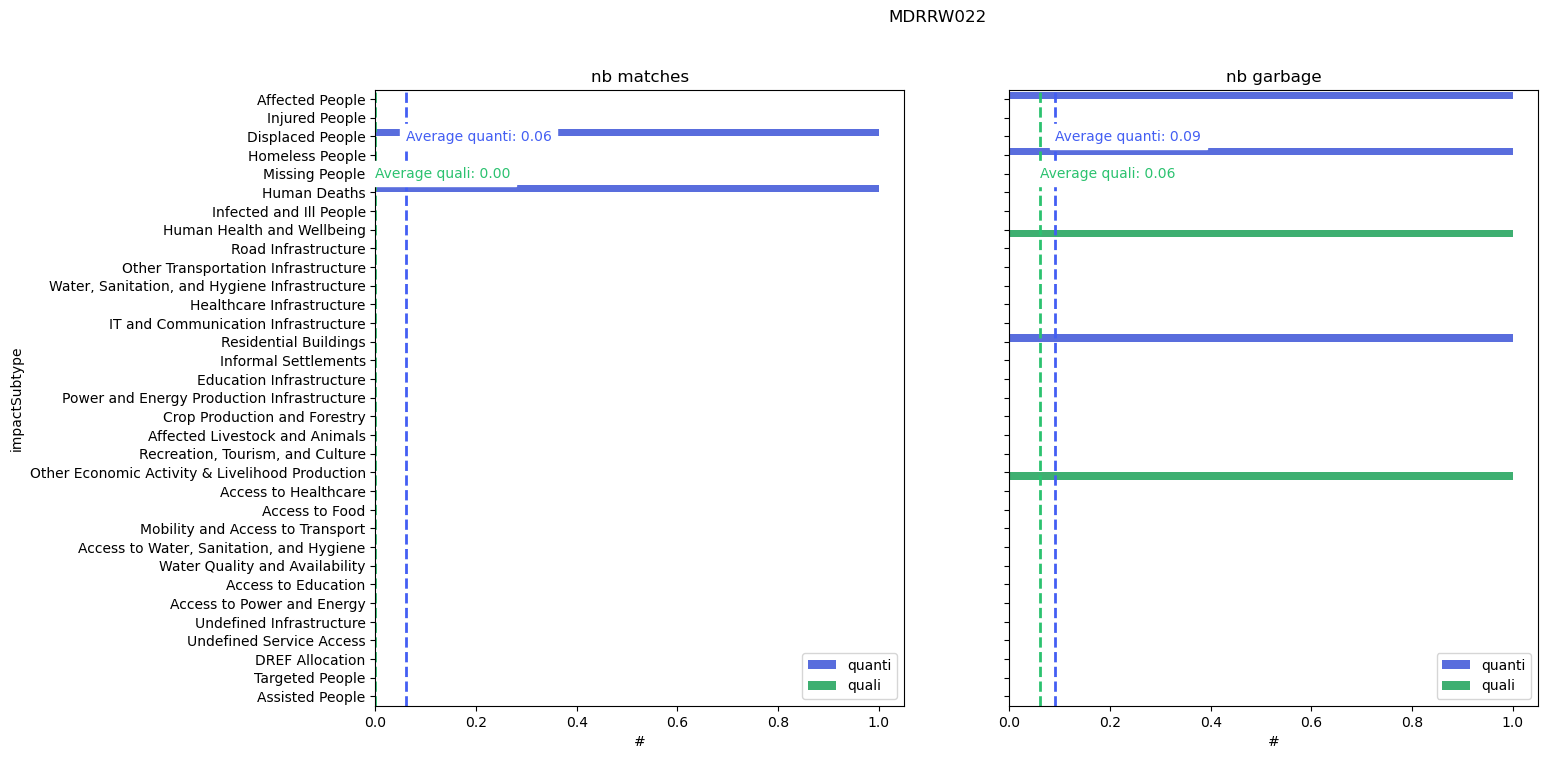

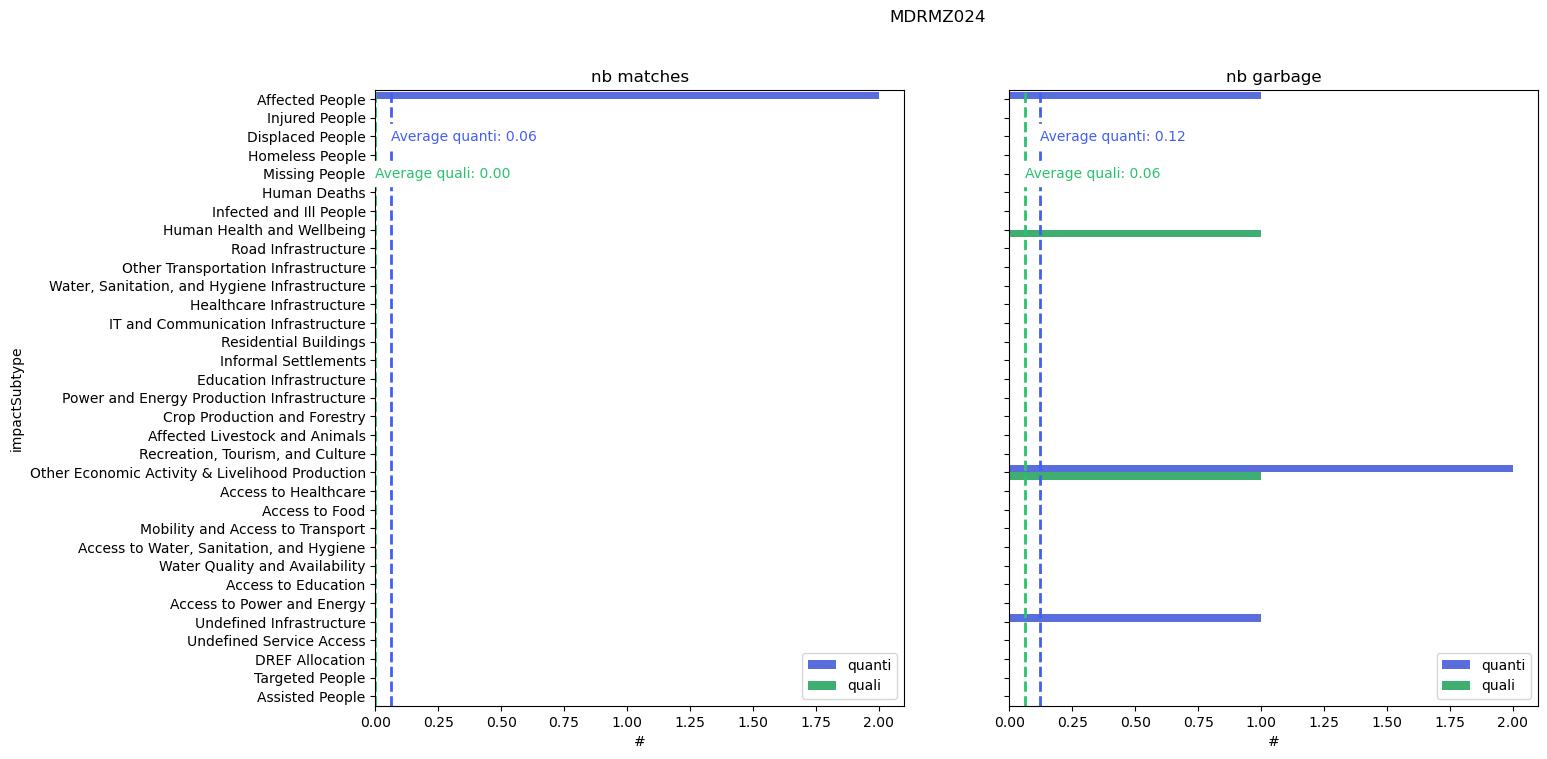

In [24]:
#coverage vs garbage per impactSubtype for each report
appeals = labelled_df.appealCode.unique()
value_vars = ["nb matches", "nb garbage"]#["coverage matches", "garbage"]#["nb matches", "nb garbage"]
label = "#"
yvar="impactSubtype"
#fig, axes = plt.subplots(len(appeals), 2, figsize=(15, 10), sharey=True)
#choose plotting cols
subplot_col = "match"#"quanti""match"
hue_col = "quanti"#"quanti""match"
palette_rel = ["#E61F04", "#f46c6c","#177093","#27a4d6"]
palette_rel = ["#435EF3", "#2bc26f","#435EF3", "#2bc26f", "#435EF3", "#2bc26f"]

for i, appeal in enumerate(appeals):
    ext_appeal = extracted_df_filter[extracted_df_filter["appealCode"] == appeal]
    lab_appeal = labelled_df_filter[labelled_df_filter["appealCode"] == appeal]
    matched_appeal = matched_df_filter2[matched_df_filter2["appealCode"] == appeal]
    coverage_df_match_appeal_subtype = make_coverage_accuracy_df(ext_appeal, lab_appeal, matched_appeal, group_key="impactSubtype", group_keys=IMPACT_SUBTYPES).reset_index(drop=False, names=["impactSubtype"])
    plot_df = coverage_df_match_appeal_subtype.melt(id_vars=[yvar, "quanti"], value_vars=value_vars, var_name="match", value_name="value")
    fig, axes = plot_coverage_match_v2(plot_df, subplot_col, hue_col, yvar=yvar, value_col="value", palette=palette_rel, add_avg=add_avg)
    [ax.set_xlabel(label) for ax in axes]
    fig.suptitle(appeal)

In [135]:
appeal="MDRCM039"
ext_appeal = extracted_df_filter[extracted_df_filter["appealCode"] == appeal]
lab_appeal = labelled_df_filter[labelled_df_filter["appealCode"] == appeal]
matched_appeal = matched_df[matched_df["appealCode"] == appeal]
matched_appeal_flt = matched_df_filter2[matched_df_filter2["appealCode"] == appeal]
coverage_df_match_appeal_subtype = make_coverage_accuracy_df(ext_appeal, lab_appeal, matched_appeal_flt, group_key="impactSubtype", group_keys=["Targeted People"]).reset_index(drop=False, names=["impactSubtype"])

In [136]:
coverage_df_match_appeal_subtype

,impactSubtype,nb labelled,nb extracted,coverage,nb matches,coverage matches,nb garbage,garbage,garbage/coverage,quanti
0,Targeted People,0,0,NaN,0,NaN,0,0,NaN,quanti
1,Targeted People,0,0,NaN,0,NaN,0,0,NaN,quali


In [137]:
print_match(matched_appeal[matched_appeal["match_sim"] < 0.6])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
51,MDRCM039,Targeted People,Affected People,4800.000000,400.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
52,MDRCM039,Targeted People,Affected People,4800.000000,200.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Mokolo district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
53,MDRCM039,DREF Allocation,Affected People,448994.353894,158620.00,EUR,null,"['Far North region', 'Extrême-Nord', 'Logone e...",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","[""Appeal MDRCM039 Country Cameroon Hazard Floo..."
54,MDRCM039,DREF Allocation,Affected People,448994.353894,400.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
55,MDRCM039,DREF Allocation,Affected People,448994.353894,200.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Mokolo district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
58,MDRCM039,Agricultural Infrastructure,Crop Production and Forestry,29.980000,29.98,km**2 of crop production and forestry,km**2 of crop production and forestry,"['Logone et Chari', 'Mayo Danay']",['Far North region'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.558830,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
61,MDRCM039,Displaced People,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Yagoua', 'Blangoua', 'Mackary', 'Zina', 'Mag...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.592593,['Tens of thousands of victims are currently l...,['The peak of the floods was recorded on Augus...
62,MDRCM039,Homeless People,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Yagoua', 'Blangoua', 'Mackary', 'Zina', 'Mag...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.592593,['Tens of thousands of victims are currently l...,['The peak of the floods was recorded on Augus...
63,MDRCM039,Access to Food,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Far North region', 'Logone et Chari division...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.707107,0.496823,['The lack of communication with the community...,['The peak of the floods was recorded on Augus...
64,MDRCM039,"Access to Water, Sanitation, and Hygiene",Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Logone et Chari division', 'Mayo Danay divis...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.518519,['Water sources (wells and water points) have ...,['The peak of the floods was recorded on Augus...


In [138]:
print_match(matched_appeal)

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
49,MDRCM039,Affected People,Affected People,158620.000000,400.00,people,people,"['Logone et Chari division', 'Mayo Danay divis...",['Ndoukoula district'],1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.826087,['The provisional report consolidated by the w...,"['Notably, in the Diamar division, where Ndouk..."
50,MDRCM039,Affected People,Affected People,158620.000000,200.00,people,people,"['Logone et Chari division', 'Mayo Danay divis...",['Mokolo district'],1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.826087,['The provisional report consolidated by the w...,"['Notably, in the Diamar division, where Ndouk..."
51,MDRCM039,Targeted People,Affected People,4800.000000,400.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
52,MDRCM039,Targeted People,Affected People,4800.000000,200.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Mokolo district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
53,MDRCM039,DREF Allocation,Affected People,448994.353894,158620.00,EUR,null,"['Far North region', 'Extrême-Nord', 'Logone e...",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","[""Appeal MDRCM039 Country Cameroon Hazard Floo..."
54,MDRCM039,DREF Allocation,Affected People,448994.353894,400.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
55,MDRCM039,DREF Allocation,Affected People,448994.353894,200.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Mokolo district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
56,MDRCM039,Residential Buildings,Residential Buildings,8690.000000,8690.00,homes,homes,"['Logone et Chari division', 'Mayo Danay divis...",['Far North region'],1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.806380,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
57,MDRCM039,Affected Livestock and Animals,Affected Livestock and Animals,10178.000000,10178.00,affected animals,affected animals,"['Logone et Chari', 'Mayo Danay']",['Far North region'],1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.819700,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
58,MDRCM039,Agricultural Infrastructure,Crop Production and Forestry,29.980000,29.98,km**2 of crop production and forestry,km**2 of crop production and forestry,"['Logone et Chari', 'Mayo Danay']",['Far North region'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.558830,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...


In [139]:
print_match(matched_df_filter2[(matched_df_filter2["match_sim"]<0.6) & (matched_df_filter2["appealCode"]=="MDRKE058")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched


In [140]:
print_match(matched_appeal[matched_appeal["impactSubtype"]=="Access to Power and Energy"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched


In [141]:
matched_appeal[matched_appeal["impactSubtype"]=="Affected People"]#[["appealCode","impactSubtype", "impactSubtype_matched", "impactValue", "impactValue_matched", "impactUnit", "impactUnit_matched", "location", "location_matched", "impactSubtype_sim", "impactUnit_sim", "geometry_sim","hazards_sim","match_sim","valueAnnotation", "annotation_matched"]]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,country,location,...,endDay_sim,impactSubtype_sim,impactUnit_sim,geometry_sim,impactValue_sim,match_sim,impactValue_error,quanti,appealType,flag_remove_cat
49,Affected People,158620.0,NaN,NaN,exact,people,['The provisional report consolidated by the w...,0,['Cameroon'],"['Logone et Chari division', 'Mayo Danay divis...",...,1.0,1.0,1.0,1.0,0.0,0.826087,395.55,quanti,DREF Operation,False
50,Affected People,158620.0,NaN,NaN,exact,people,['The provisional report consolidated by the w...,0,['Cameroon'],"['Logone et Chari division', 'Mayo Danay divis...",...,1.0,1.0,1.0,1.0,0.0,0.826087,792.10,quanti,DREF Operation,False


In [142]:
print_match(matched_df_filter1[(matched_df_filter1["match_sim"]<0.6) & (matched_df_filter1["appealCode"]=="MDRBD022")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
15,MDRBD022,Access to Healthcare,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.570748,['Six days of heavy rain and onrush of upstrea...,['It is also reported that embankments have be...
16,MDRBD022,Access to Healthcare,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Gaddimari area', 'Lalmonirhats Hatibandha']",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.570748,['Six days of heavy rain and onrush of upstrea...,['of union affected 776 Emergency Plan of Acti...


In [143]:
print_match(matched_df[(matched_df["impactSubtype"]=="Informal Settlements")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
173,MDRKE058,Informal Settlements,Infected and Ill People,10.0,8.0,informal settlements,people,"['Busia County', 'Kisumu', 'Homabay', 'Migori'...",['Garsen'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.707107,0.280744,['49 camps have been set up within the last tw...,['October November December short rains season...
174,MDRKE058,Informal Settlements,Affected People,31015.0,31015.0,people,people,"['Nairobi County', 'Kware', 'Kibra', 'Viwandan...","['Nairobi County', 'Kware', 'Kibra', 'Viwandan...",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.739130,"['In Nairobi County, 31,015 people (6,203 hous...","['In Nairobi County, 31,015 people (6,203 hous..."
504,MDRYE011,Informal Settlements,Informal Settlements,NaN,NaN,null,null,"['Al-Khamis camp', 'Al-Hasaba', 'Aser camp', '...",['Sanaa governorate'],1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.707107,0.838583,['the heavy rains affected 56 families in Al-K...,"[""Situation analysis Description of the disast..."


In [144]:
print_match(matched_df[(matched_df["impactSubtype"]=="Other Infrastructural Impacts")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
126,MDRDZ011,Other Infrastructural Impacts,"Water, Sanitation, and Hygiene Infrastructure",NaN,NaN,null,undefined WASH structures,['Béchar'],['Béchar'],0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.000000,0.481481,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
127,MDRDZ011,Other Infrastructural Impacts,Power and Energy Production Infrastructure,NaN,NaN,null,undefined power and energy production structures,['Béchar'],['Béchar'],0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.000000,0.481481,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
171,MDRKE058,Other Infrastructural Impacts,Healthcare Infrastructure,11.0,7.0,undefined structures,healthcare structures,[],[],0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.707107,0.282297,['economic activities of the areas have been s...,['October November December short rains season...
259,MDRNG041,Other Infrastructural Impacts,Other Economic Activity & Livelihood Production,NaN,NaN,null,null,"['Dantudu', 'Balakozo', 'Gidan Tudu', 'Tsitse']",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.555556,"['The floods ravaged farmlands and livestock, ...","['The scale of destruction is unprecedented, w..."
288,MDRPK026,Other Infrastructural Impacts,Other Infrastructural Impacts,NaN,NaN,null,null,"['Balochistan', 'Khyber Pakhtunkhwa', 'Sindh',...","['Jacobabad', 'Naushero Feroz', 'Ghotki', 'Suk...",1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.941267,['The monsoon season causing significant infra...,"['Areas such as Jacobabad, Naushero Feroz, Gho..."
370,MDRRW022,Other Infrastructural Impacts,IT and Communication Infrastructure,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
371,MDRRW022,Other Infrastructural Impacts,Power and Energy Production Infrastructure,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
372,MDRRW022,Other Infrastructural Impacts,Access to Healthcare,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
373,MDRRW022,Other Infrastructural Impacts,Mobility and Access to Transport,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
374,MDRRW022,Other Infrastructural Impacts,Access to Education,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."


In [145]:
matched_df[matched_df["match_sim"]<0.6]["impactUnit"].value_counts()

impactUnit
null                                     242
EUR                                       66
people                                    24
%                                          3
percent                                    2
km**2 of crop production and forestry      1
yuan                                       1
undefined structures                       1
informal settlements                       1
women                                      1
children under 5                           1
children                                   1
Name: count, dtype: int64

In [146]:
extracted_df[extracted_df["appealCode"]=="MDRMZ024"][["impactUnit", "flag_percent"]]

,impactUnit,flag_percent
47,people,False
48,people,False
49,people,False
50,people,False
51,km**2 of crop production and forestry,False
52,null,False
53,EUR,False
54,EUR,False
55,people,False
56,EUR,False


In [147]:
labelled_df[labelled_df["appealCode"]=="MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry,quanti,appealType,flag_remove_cat
474,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
475,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
476,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
477,2024-09-05,Water Quality and Availability,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
478,2024-09-05,Road Infrastructure,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
479,2024-09-05,"Water, Sanitation, and Hygiene Infrastructure",NaN,WASH structures,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
480,2024-09-05,Crop Production and Forestry,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
481,2024-09-05,Affected Livestock and Animals,NaN,affected animals,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
482,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
483,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,ADM_1,0,0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Western Province', 'Western Province', 'West...",['RWA'],"MULTIPOLYGON (((29.0405 -2.73948, 29.0405 -2.7...",quanti,DREF Operation Final Report,False


In [148]:
labelled_df[labelled_df["appealCode"]=="MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry,quanti,appealType,flag_remove_cat
474,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
475,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
476,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
477,2024-09-05,Water Quality and Availability,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
478,2024-09-05,Road Infrastructure,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
479,2024-09-05,"Water, Sanitation, and Hygiene Infrastructure",NaN,WASH structures,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
480,2024-09-05,Crop Production and Forestry,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
481,2024-09-05,Affected Livestock and Animals,NaN,affected animals,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
482,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
483,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,ADM_1,0,0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Western Province', 'Western Province', 'West...",['RWA'],"MULTIPOLYGON (((29.0405 -2.73948, 29.0405 -2.7...",quanti,DREF Operation Final Report,False


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of t

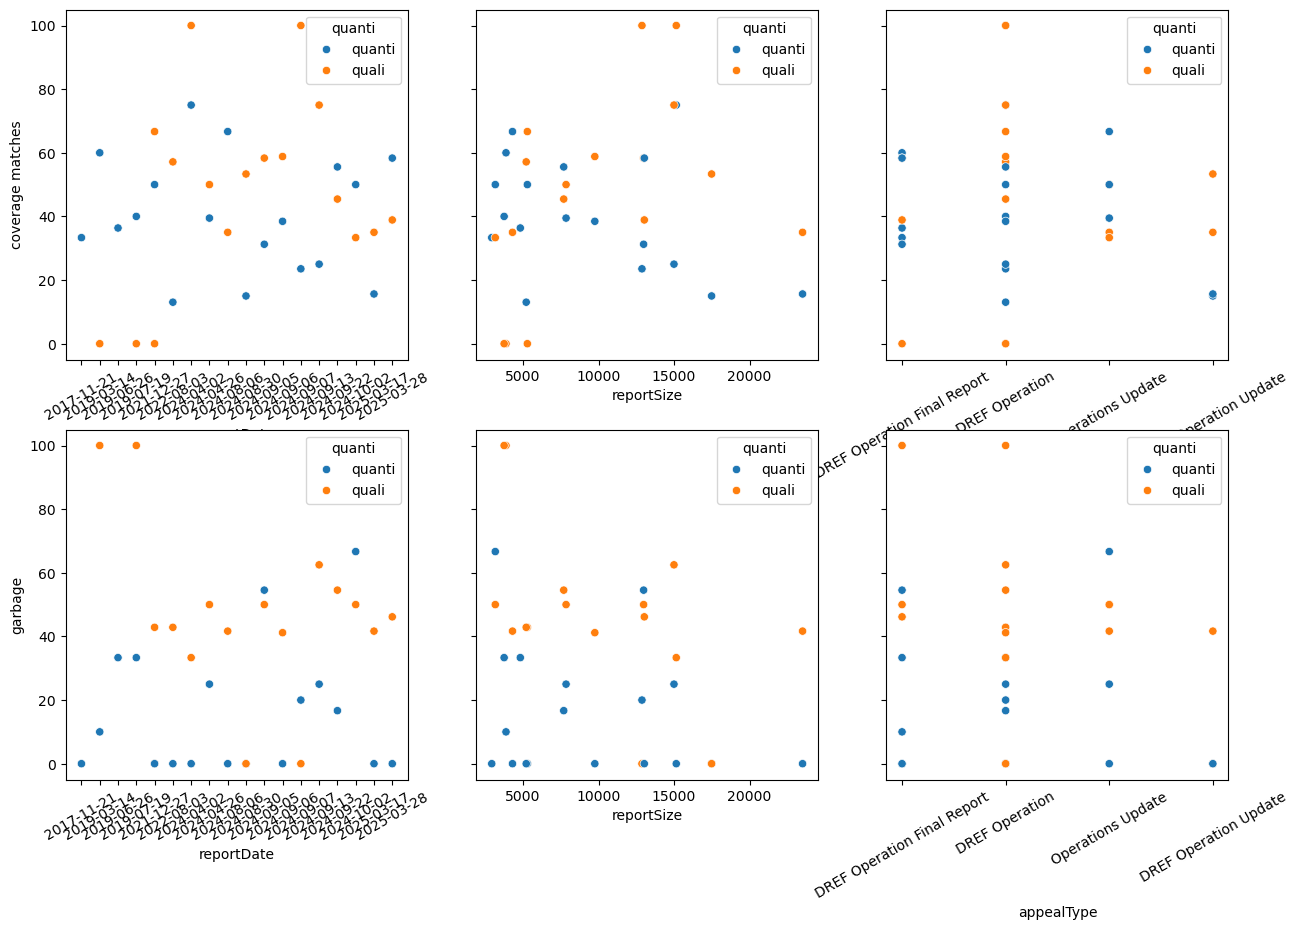

In [12]:
#inspect sensitivity to other variables e.g. date report type, lentgth
external_vars = ["reportDate", "reportSize", "appealType"]
fig, axes = plt.subplots(2, len(external_vars), figsize=(15, 10), sharey=True, sharex=False)
coverage_df_match_appeal = coverage_df_match_appeal.sort_values("reportDate")
for i, var in enumerate(external_vars):
    sns.scatterplot(coverage_df_match_appeal, x=var, y="coverage matches", hue="quanti", ax=axes[0, i])
    sns.scatterplot(coverage_df_match_appeal, x=var, y="garbage", hue="quanti", ax=axes[1, i])
    if var in ["reportDate", "appealType"]:
        axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
        axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
fig.savefig(DATA_FIGURE / f"coverage_matches_by_{yvar}_external_vars_valerr_th-{value_error_th}_sim_th-{sim_th}_{filename_match}.png", bbox_inches="tight", dpi=300)

In [150]:
#inspect sensitivity to thresholds

value_error_ths = np.arange(0.01, 0.3, 0.01)
sim_ths = np.arange(0.2, 1, 0.1)
vth_scores = []
for vth in value_error_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=vth, sim_th=0.6)
    make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None)
    vth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])

sth_scores = []
for sth in sim_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=0.1, sim_th=sth)
    sth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])


Overall average quanti: 176 extracted, 336 labelled, 96 correct matches, 80 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 96 correct matches, 80 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 97 correct matches, 79 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 97 correct matches, 79 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 98 correct matches, 78 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 98 correct matches, 78 garbage m

<Axes: >

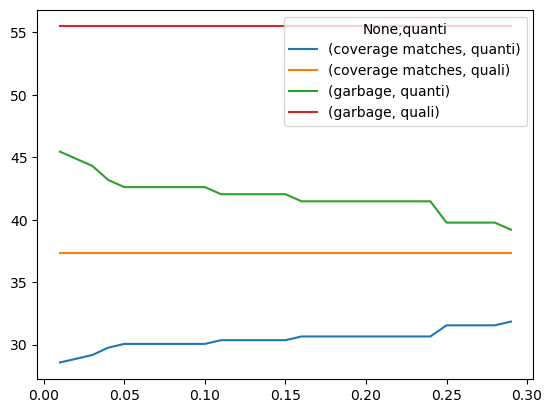

In [151]:
sensi_vth_df = pd.concat(vth_scores, keys=value_error_ths).unstack()
sensi_vth_df.plot()

<Axes: >

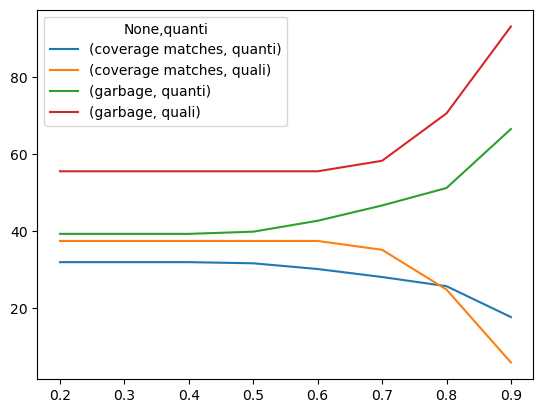

In [152]:
sensi_sth_df = pd.concat(sth_scores, keys=sim_ths).unstack()
sensi_sth_df.plot()

In [4]:
## Compare coverage by categories between labelled and extracted for all impacts

keys = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
key = keys[0]
extracted_lab_name = f"merged_subtypes_post_processed_labelled_reports_fixed_impact_desc_{key}_v271025"
extracted_all_name = f"merged_subtypes_post_processed_all_appeals_unique_1-333_{key}_v281025"

extracted_lab = pd.read_csv(DATA_OUT_PROC / (extracted_lab_name+".csv"))
extracted_df_long = pd.read_csv(DATA_OUT_PROC / (extracted_all_name+".csv"))


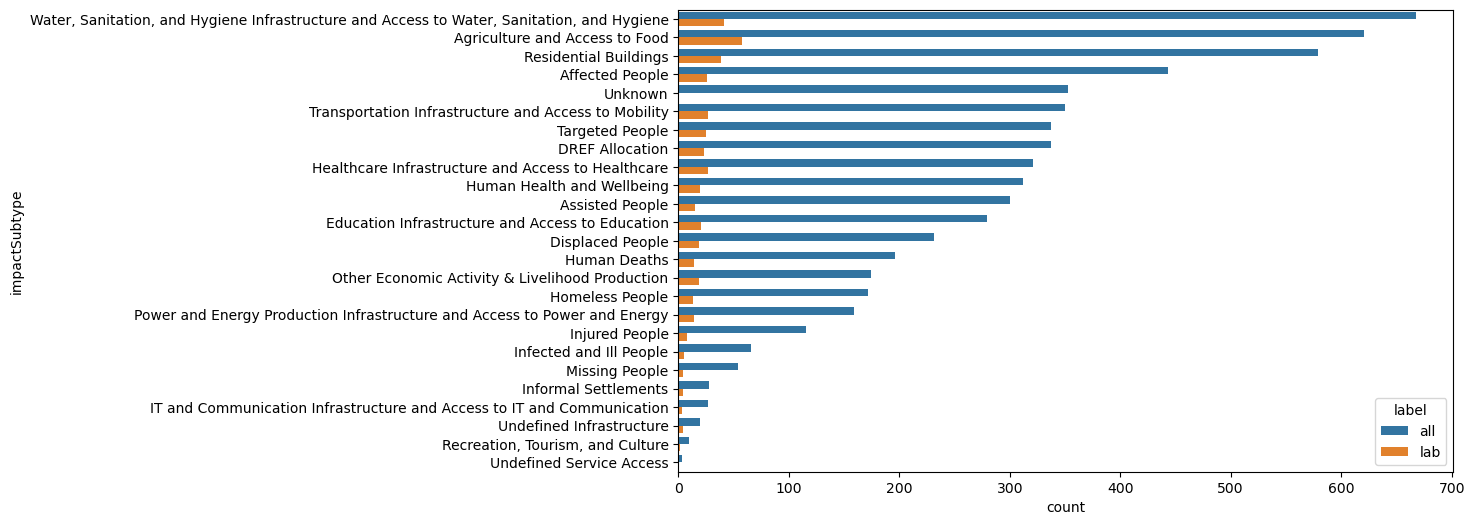

In [5]:
#merge dfs
extracted_lab["label"] ="lab"
extracted_df_long["label"] = "all"
extracted_df_all = pd.concat([extracted_lab, extracted_df_long])
plot_df = extracted_df_all.value_counts(["impactSubtype", "label"]).reset_index()
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.barplot(data=plot_df, x="count", y="impactSubtype", hue="label", axes=ax)
fig.savefig(DATA_FIGURE / f"impactSubtype_distr_lab_vs_333_{extracted_lab_name}.png", bbox_inches="tight", dpi=300)
